# 第13讲: 生成模型
## GAN, VAE, Diffusion

**CS231n: 深度学习与计算机视觉**

本notebook从直觉到代码,深入理解三大生成模型范式。

### 四步学习路径
1. **直觉理解** -- 生成模型的目标,三大范式的核心思想
2. **手动计算** -- GAN损失、VAE的ELBO、Diffusion噪声调度的数值推导
3. **代码实现** -- 用NumPy从零实现GAN、VAE和Diffusion
4. **实验观察** -- 可视化生成过程,分析训练动态


## 学习目标

完成本notebook后,你将能够:

- 解释 **生成模型** 与判别模型的本质区别
- 理解 **GAN** 的对抗训练机制和损失函数
- 推导 **VAE** 的变分下界 (ELBO) 和重参数化技巧
- 理解 **Diffusion** 的前向加噪和反向去噪过程
- 手动计算三种模型的核心损失函数
- 用NumPy实现三种生成模型的基本组件
- 通过实验观察生成模型的训练动态和生成质量

### 前置知识
- 深度学习基础 (lecture-6)
- 概率论基础 (高斯分布, KL散度)
- NumPy线性代数


---
# Part 1: 直觉理解

## 1.1 生成模型 vs 判别模型

### 判别模型
- **目标**: 学习 $p(y|x)$ (给定输入,预测标签)
- **例子**: 分类器, 目标检测器
- **能力**: 判断、分类, 但不能创造新样本

### 生成模型
- **目标**: 学习 $p(x)$ 或 $p(x|y)$ (数据的分布)
- **能力**: 生成新的、从未见过的数据样本
- **应用**: 图像生成, 数据增强, 异常检测, 域迁移

### 三大生成范式

| 范式 | 核心思想 | 代表方法 | 优势 | 劣势 |
|------|---------|---------|------|------|
| **GAN** | 对抗训练 | DCGAN, StyleGAN | 高质量样本 | 训练不稳定 |
| **VAE** | 变分推断 | VAE, beta-VAE | 稳定训练, 显式分布 | 样本模糊 |
| **Diffusion** | 噪声去噪 | DDPM, Stable Diffusion | 最优质量 | 采样速度慢 |


Figure saved: nb10_gen_vs_disc.png


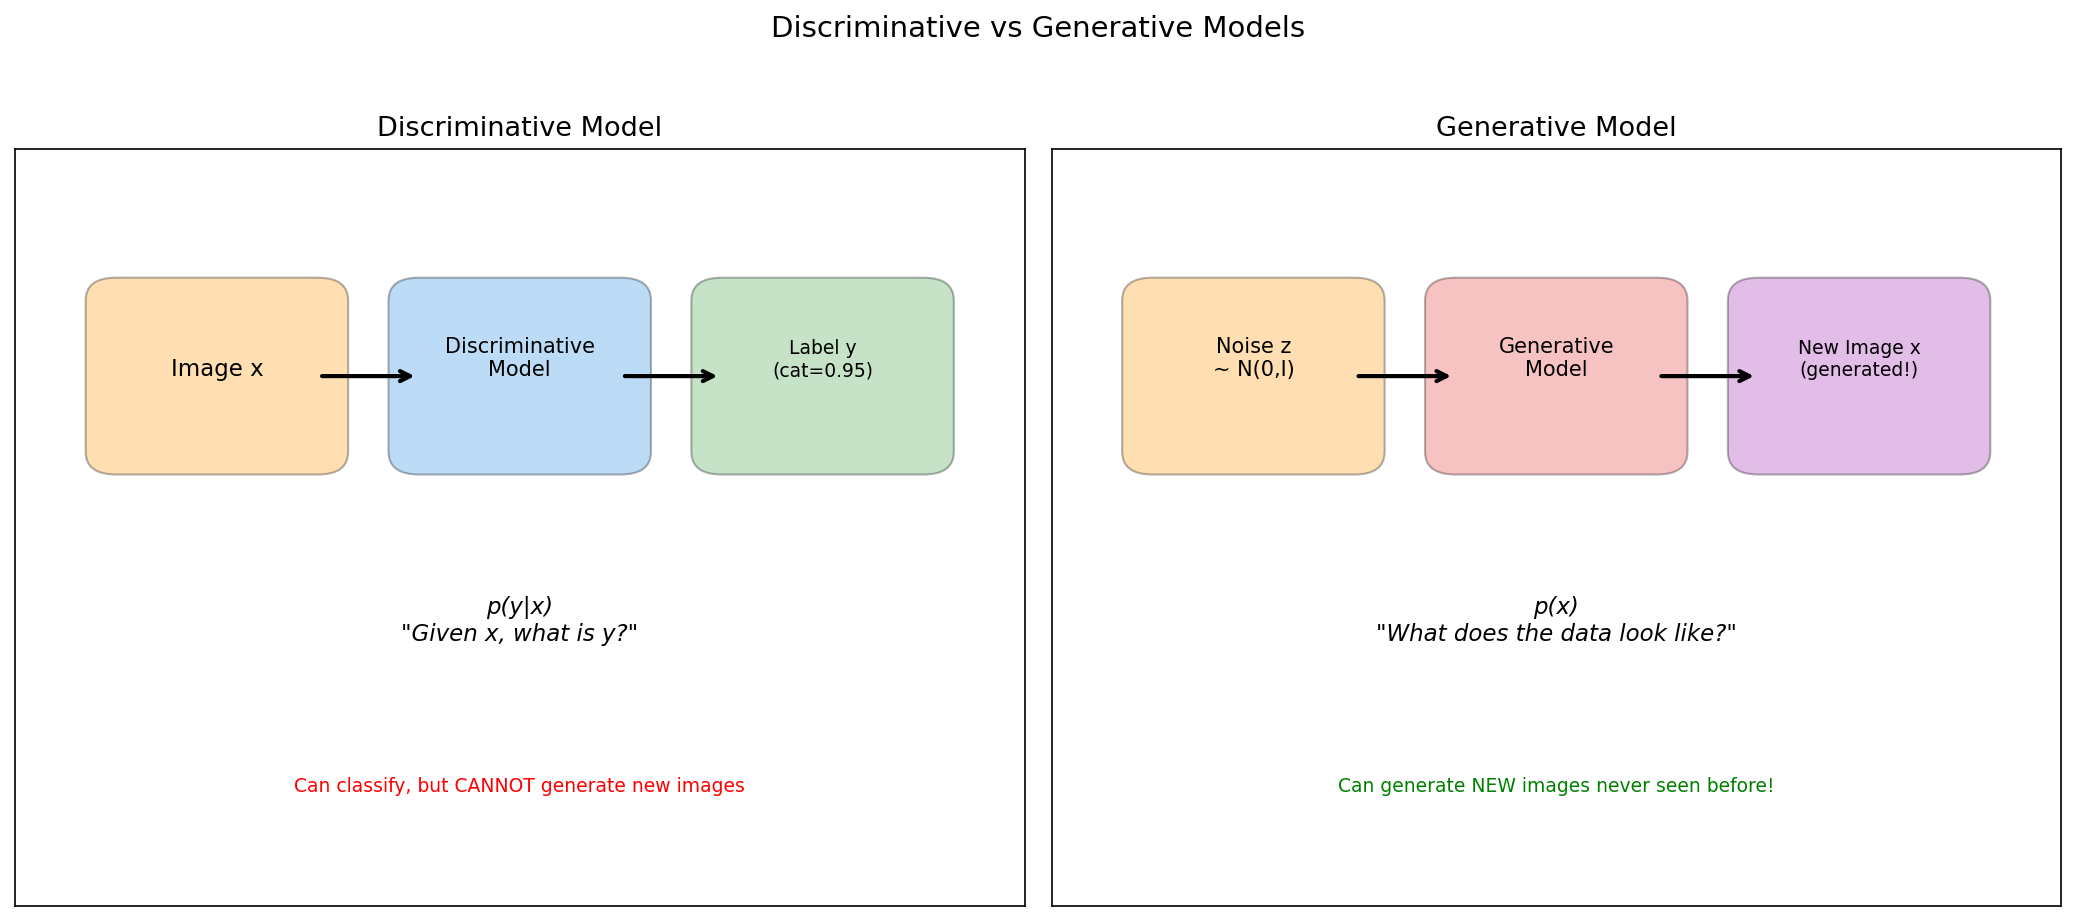

In [4]:
# Visualize: Generative vs Discriminative models
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Discriminative model
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.add_patch(FancyBboxPatch((1, 6), 2, 2, boxstyle='round', facecolor='#FF9800', alpha=0.3))
ax.text(2, 7, 'Image x', ha='center', fontsize=11)
ax.add_patch(FancyBboxPatch((4, 6), 2, 2, boxstyle='round', facecolor='#1E88E5', alpha=0.3))
ax.text(5, 7, 'Discriminative\nModel', ha='center', fontsize=10)
ax.add_patch(FancyBboxPatch((7, 6), 2, 2, boxstyle='round', facecolor='#43A047', alpha=0.3))
ax.text(8, 7, 'Label y\n(cat=0.95)', ha='center', fontsize=9)
for xy_from, xy_to in [((3, 7), (4, 7)), ((6, 7), (7, 7))]:
    ax.annotate('', xy=xy_to, xytext=xy_from, arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.text(5, 3.5, 'p(y|x)\n"Given x, what is y?"', ha='center', fontsize=11, style='italic')
ax.text(5, 1.5, 'Can classify, but CANNOT generate new images', ha='center', fontsize=9, color='red')
ax.set_title('Discriminative Model', fontsize=13)
ax.set_xticks([]); ax.set_yticks([])

# Generative model
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.add_patch(FancyBboxPatch((1, 6), 2, 2, boxstyle='round', facecolor='#FF9800', alpha=0.3))
ax.text(2, 7, 'Noise z\n~ N(0,I)', ha='center', fontsize=10)
ax.add_patch(FancyBboxPatch((4, 6), 2, 2, boxstyle='round', facecolor='#E53935', alpha=0.3))
ax.text(5, 7, 'Generative\nModel', ha='center', fontsize=10)
ax.add_patch(FancyBboxPatch((7, 6), 2, 2, boxstyle='round', facecolor='#9C27B0', alpha=0.3))
ax.text(8, 7, 'New Image x\n(generated!)', ha='center', fontsize=9)
for xy_from, xy_to in [((3, 7), (4, 7)), ((6, 7), (7, 7))]:
    ax.annotate('', xy=xy_to, xytext=xy_from, arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.text(5, 3.5, 'p(x)\n"What does the data look like?"', ha='center', fontsize=11, style='italic')
ax.text(5, 1.5, 'Can generate NEW images never seen before!', ha='center', fontsize=9, color='green')
ax.set_title('Generative Model', fontsize=13)
ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Discriminative vs Generative Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('nb10_gen_vs_disc.png', dpi=150)
plt.show()
print("Figure saved: nb10_gen_vs_disc.png")


## 1.2 GAN: 对抗博弈

### GAN的核心思想 (Goodfellow, 2014)

> **生成器和判别器进行博弈 (minimax game), 在对抗中共同进步。**

### 角色分配

- **生成器 G**: 造假者, 从噪声生成假样本, 目标是骗过判别器
- **判别器 D**: 鉴别者, 区分真实样本和假样本, 目标是识破生成器

### 训练过程

1. 训练 D: 固定G, 让D更好地分辨真假
2. 训练 G: 固定D, 让G生成更逼真的样本骗过D
3. 交替进行, 直到达到纳什均衡

### 直觉类比

- 造假者 vs 警察
- 造假者越来越精, 警察也越来越厉害
- 最终假钞和真钞无法区分

### GAN的问题
1. **模式崩溃**: G只生成少数几种样本
2. **训练不稳定**: D和G失衡导致崩溃
3. **评估困难**: 没有统一的生成质量指标


Figure saved: nb10_gan_progress.png

Goal: Generator's fake distribution matches real distribution
At equilibrium: D(x) = 0.5 (cannot distinguish)


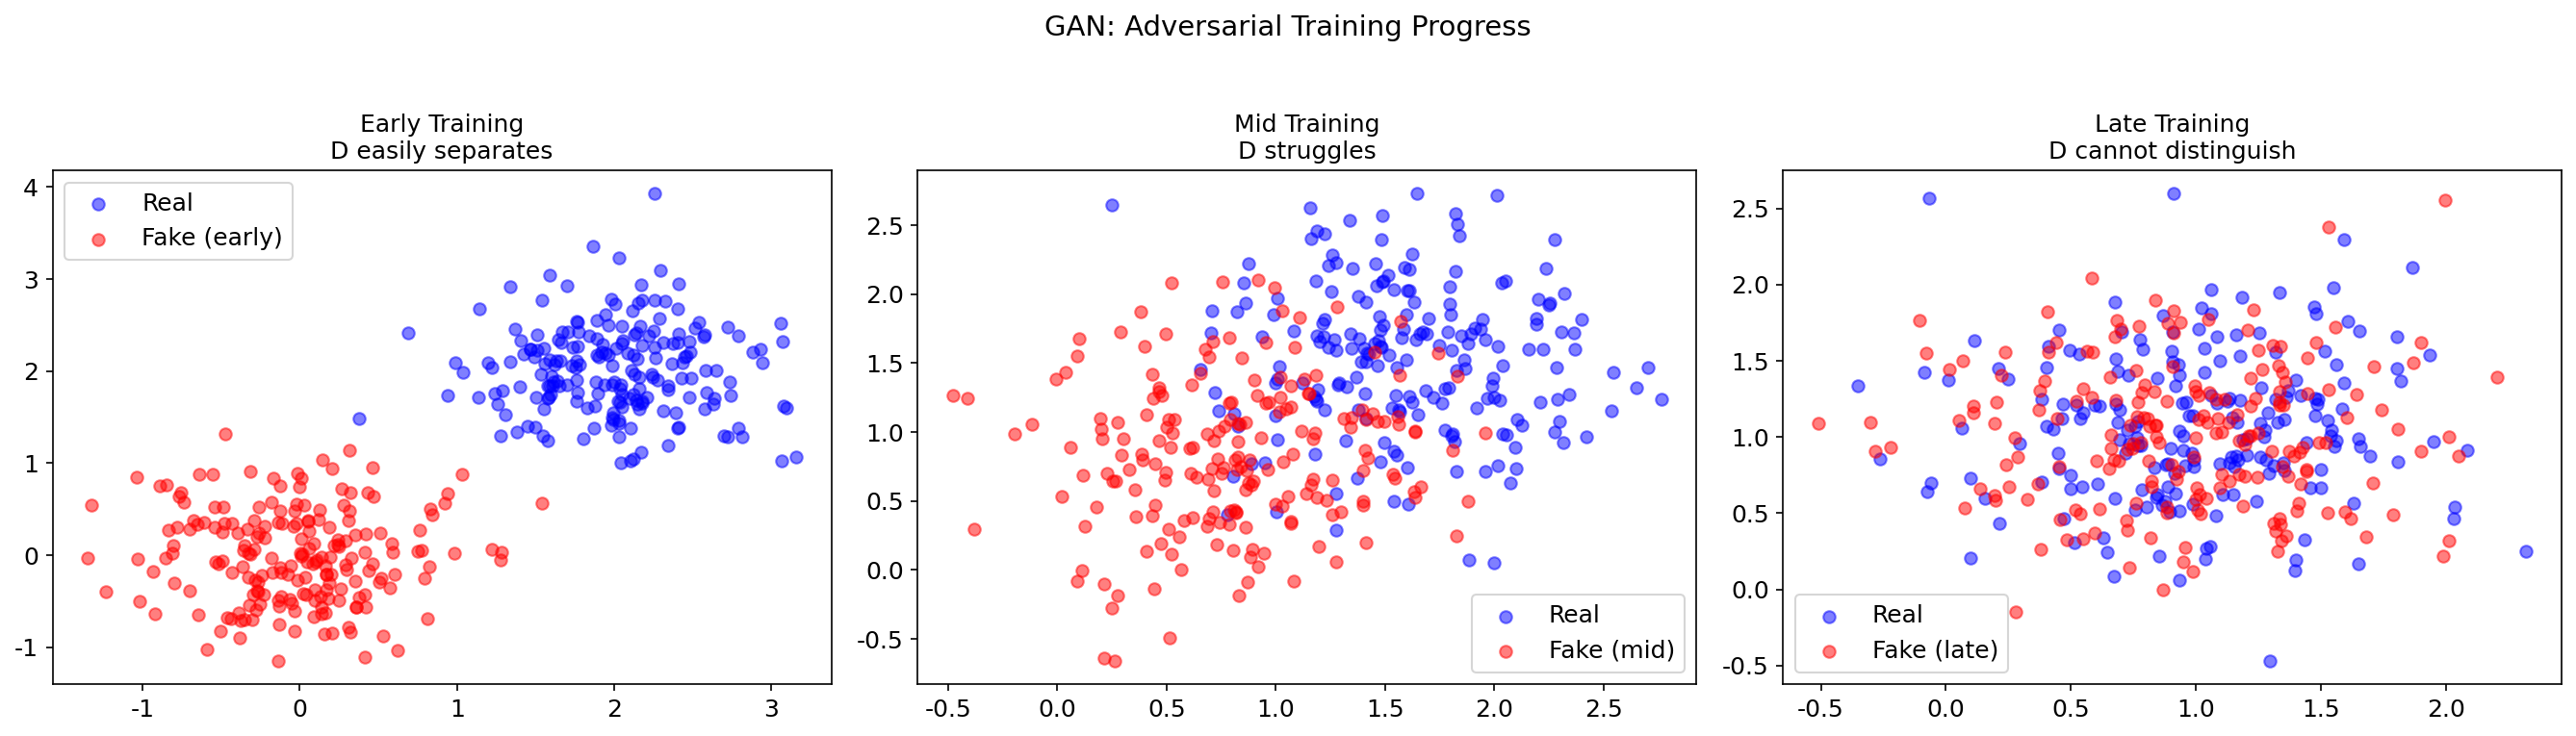

In [6]:
# Visualize GAN adversarial game
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Early training: G produces bad samples, D easily separates
ax = axes[0]
real = np.random.randn(200, 2) * 0.5 + 2  # real cluster
fake = np.random.randn(200, 2) * 0.5  # fake cluster (early)
ax.scatter(real[:, 0], real[:, 1], c='blue', alpha=0.5, label='Real')
ax.scatter(fake[:, 0], fake[:, 1], c='red', alpha=0.5, label='Fake (early)')
ax.set_title('Early Training\nD easily separates', fontsize=12)
ax.legend()

# Mid training: G improves, harder to separate
ax = axes[1]
real = np.random.randn(200, 2) * 0.5 + 1.5
fake = np.random.randn(200, 2) * 0.5 + 0.8  # closer to real
ax.scatter(real[:, 0], real[:, 1], c='blue', alpha=0.5, label='Real')
ax.scatter(fake[:, 0], fake[:, 1], c='red', alpha=0.5, label='Fake (mid)')
ax.set_title('Mid Training\nD struggles', fontsize=12)
ax.legend()

# Late training: G matches real distribution
ax = axes[2]
real = np.random.randn(200, 2) * 0.5 + 1.0
fake = np.random.randn(200, 2) * 0.5 + 1.0  # matches real
ax.scatter(real[:, 0], real[:, 1], c='blue', alpha=0.5, label='Real')
ax.scatter(fake[:, 0], fake[:, 1], c='red', alpha=0.5, label='Fake (late)')
ax.set_title('Late Training\nD cannot distinguish', fontsize=12)
ax.legend()

plt.suptitle('GAN: Adversarial Training Progress', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('nb10_gan_progress.png', dpi=150)
plt.show()
print("Figure saved: nb10_gan_progress.png")
print("\nGoal: Generator's fake distribution matches real distribution")
print("At equilibrium: D(x) = 0.5 (cannot distinguish)")


## 1.3 GAN损失函数

### Minimax目标

$$\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{data}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]$$

### 判别器目标 (最大化)

$$\max_D: \quad \mathbb{E}[\log D(x)] + \mathbb{E}[\log(1 - D(G(z)))]$$

- $\log D(x)$: 对真样本给高分
- $\log(1 - D(G(z)))$: 对假样本给低分

### 生成器目标 (最小化)

$$\min_G: \quad \mathbb{E}[\log(1 - D(G(z)))]$$

等价 (非饱和) 形式:
$$\max_G: \quad \mathbb{E}[\log D(G(z))]$$

- 让 $D(G(z))$ 越大越好 (假样本骗过判别器)

### 理论最优解

当达到纳什均衡时:
- $p_g = p_{data}$ (生成分布 = 真实分布)
- $D^*(x) = \frac{p_{data}(x)}{p_{data}(x) + p_g(x)} = 0.5$ (无法区分)

### JS散度

GAN最小化的是真实分布和生成分布之间的 **Jensen-Shannon散度**。


Figure saved: nb10_gan_loss.png

Equilibrium at D=0.5: neither D nor G can improve
Non-saturating G loss is more practical (better gradients when D is confident)


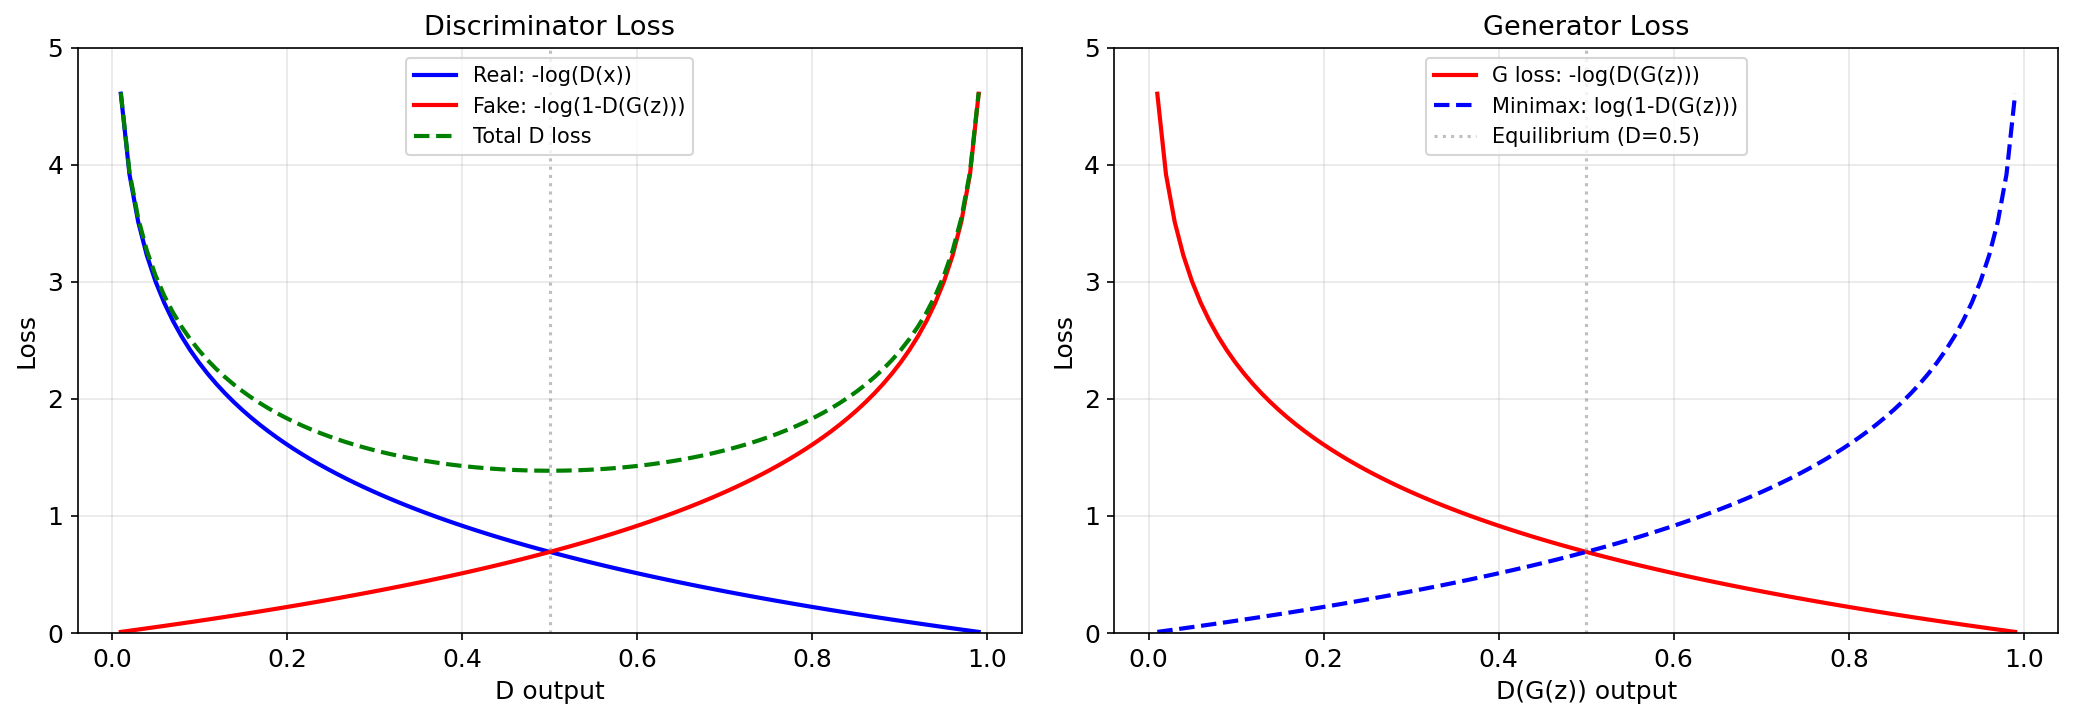

In [8]:
# Visualize GAN loss landscape
import numpy as np
import matplotlib.pyplot as plt

# D output (0=fake, 1=real)
d_output = np.linspace(0.01, 0.99, 100)

# Discriminator losses
d_loss_real = -np.log(d_output)  # want D(x) -> 1
d_loss_fake = -np.log(1 - d_output)  # want D(G(z)) -> 0
d_total = d_loss_real + d_loss_fake

# Generator loss (non-saturating)
g_loss = -np.log(d_output)  # want D(G(z)) -> 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Discriminator perspective
axes[0].plot(d_output, d_loss_real, 'b-', linewidth=2, label='Real: -log(D(x))')
axes[0].plot(d_output, d_loss_fake, 'r-', linewidth=2, label='Fake: -log(1-D(G(z)))')
axes[0].plot(d_output, d_total, 'g--', linewidth=2, label='Total D loss')
axes[0].set_xlabel('D output', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Discriminator Loss', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].set_ylim(0, 5)
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=0.5, color='gray', linestyle=':', alpha=0.5)

# Generator perspective
axes[1].plot(d_output, g_loss, 'r-', linewidth=2, label='G loss: -log(D(G(z)))')
axes[1].plot(d_output, -np.log(1-d_output), 'b--', linewidth=2, label='Minimax: log(1-D(G(z)))')
axes[1].set_xlabel('D(G(z)) output', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Generator Loss', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, 5)
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=0.5, color='gray', linestyle=':', alpha=0.5, label='Equilibrium (D=0.5)')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('nb10_gan_loss.png', dpi=150)
plt.show()
print("Figure saved: nb10_gan_loss.png")
print("\nEquilibrium at D=0.5: neither D nor G can improve")
print("Non-saturating G loss is more practical (better gradients when D is confident)")


## 1.4 VAE: 变分自编码器

### VAE核心思想 (Kingma & Welling, 2013)

> **将编码器建模为概率分布, 通过变分推断逼近真实后验。**

### VAE结构

```
Input x --[Encoder q(z|x)]--> mu, sigma --> z ~ N(mu, sigma) --[Decoder p(x|z)]--> x_recon
```

### 与普通Autoencoder的区别

| 特性 | Autoencoder | VAE |
|------|-------------|-----|
| 编码 | 确定性: z = f(x) | 概率性: z ~ q(z|x) = N(mu, sigma) |
| 潜在空间 | 无结构, 不连续 | 有结构, 连续可采样 |
| 生成 | 不能从随机z生成 | 可从z ~ N(0,I)生成 |
| 损失 | 重建误差 | 重建 + KL散度 |

### VAE的优势
1. **潜在空间连续**: 相近的z生成相似的样本
2. **可采样生成**: 从先验分布采样, 解码生成新样本
3. **训练稳定**: ELBO有明确的梯度
4. **概率框架**: 理论基础扎实


## 1.5 VAE损失: ELBO (证据下界)

### 目标: 最大化 $\log p(x)$

由于 $p(x)$ 难以直接计算, 最大化其变分下界 (ELBO):

$$\mathcal{L}(x) = \mathbb{E}_{q(z|x)}[\log p(x|z)] - KL(q(z|x) \| p(z))$$

### 两项解释

1. **重建项** $\mathbb{E}[\log p(x|z)]$:
   - 解码器从z重建x的似然
   - 越大 = 重建越好

2. **正则项** $KL(q(z|x) \| p(z))$:
   - 编码器分布与先验的KL散度
   - 越小 = z分布越接近标准正态
   - 使潜在空间规整化, 便于生成

### 假设 $q(z|x) = \mathcal{N}(\mu, \text{diag}(\sigma^2))$, $p(z) = \mathcal{N}(0, I)$

KL散度有解析解:

$$KL = -\frac{1}{2} \sum_{j=1}^{d} (1 + \log(\sigma_j^2) - \mu_j^2 - \sigma_j^2)$$

### 重参数化技巧 (Reparameterization Trick)

不能直接对 $z \sim q(z|x)$ 求梯度, 改写为:

$$z = \mu + \sigma \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

这样梯度可以通过 $\mu$ 和 $\sigma$ 反向传播。


Figure saved: nb10_vae_architecture.png


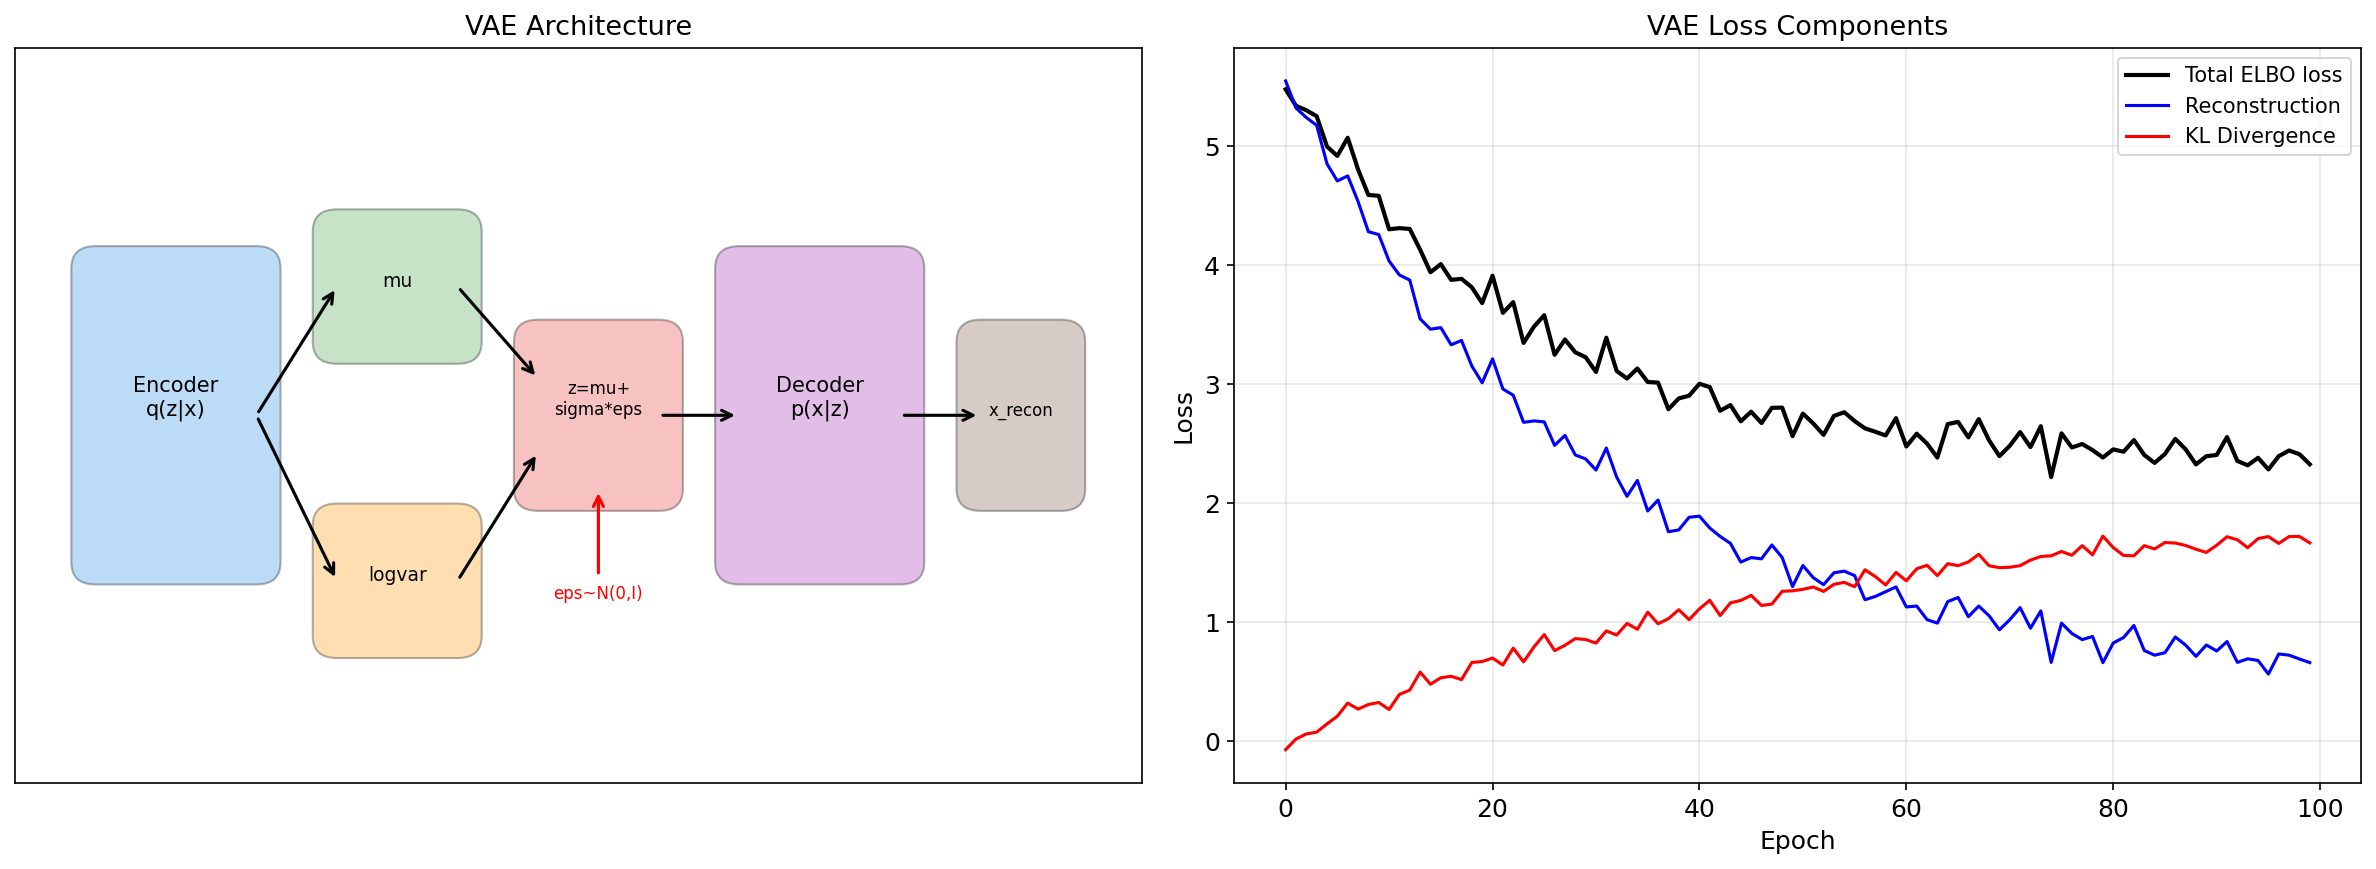

In [11]:
# Visualize VAE architecture and ELBO
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Ellipse

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# VAE architecture
ax = axes[0]
ax.set_xlim(0, 14); ax.set_ylim(0, 10)

# Encoder
ax.add_patch(FancyBboxPatch((1, 3), 2, 4, boxstyle='round', facecolor='#1E88E5', alpha=0.3))
ax.text(2, 5, 'Encoder\nq(z|x)', ha='center', fontsize=10)

# mu, logvar
ax.add_patch(FancyBboxPatch((4, 6), 1.5, 1.5, boxstyle='round', facecolor='#43A047', alpha=0.3))
ax.text(4.75, 6.75, 'mu', ha='center', fontsize=9)
ax.add_patch(FancyBboxPatch((4, 2), 1.5, 1.5, boxstyle='round', facecolor='#FF9800', alpha=0.3))
ax.text(4.75, 2.75, 'logvar', ha='center', fontsize=9)

# Reparameterize
ax.add_patch(FancyBboxPatch((6.5, 4), 1.5, 2, boxstyle='round', facecolor='#E53935', alpha=0.3))
ax.text(7.25, 5, 'z=mu+\nsigma*eps', ha='center', fontsize=8)

# Decoder
ax.add_patch(FancyBboxPatch((9, 3), 2, 4, boxstyle='round', facecolor='#9C27B0', alpha=0.3))
ax.text(10, 5, 'Decoder\np(x|z)', ha='center', fontsize=10)

# Output
ax.add_patch(FancyBboxPatch((12, 4), 1, 2, boxstyle='round', facecolor='#795548', alpha=0.3))
ax.text(12.5, 5, 'x_recon', ha='center', fontsize=8)

# Arrows
for xy_from, xy_to in [((3, 5), (4, 6.75)), ((3, 5), (4, 2.75)),
                        ((5.5, 6.75), (6.5, 5.5)), ((5.5, 2.75), (6.5, 4.5)),
                        ((8, 5), (9, 5)), ((11, 5), (12, 5))]:
    ax.annotate('', xy=xy_to, xytext=xy_from, arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# eps input
ax.text(7.25, 2.5, 'eps~N(0,I)', ha='center', fontsize=8, color='red')
ax.annotate('', xy=(7.25, 4), xytext=(7.25, 2.8), arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

ax.set_title('VAE Architecture', fontsize=13)
ax.set_xticks([]); ax.set_yticks([])

# ELBO components
ax = axes[1]
np.random.seed(42)
epochs = np.arange(100)
recon_loss = 5 * np.exp(-epochs/30) + 0.5 + np.random.randn(100) * 0.1
kl_loss = 2 * (1 - np.exp(-epochs/50)) + np.random.randn(100) * 0.05
total = recon_loss + kl_loss

ax.plot(epochs, total, 'k-', linewidth=2, label='Total ELBO loss')
ax.plot(epochs, recon_loss, 'b-', linewidth=1.5, label='Reconstruction')
ax.plot(epochs, kl_loss, 'r-', linewidth=1.5, label='KL Divergence')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('VAE Loss Components', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('nb10_vae_architecture.png', dpi=150)
plt.show()
print("Figure saved: nb10_vae_architecture.png")


## 1.6 Diffusion: 噪声与去噪

### Diffusion核心思想 (Ho et al., 2020)

> **通过逐步加噪声将数据变为纯噪声,再学习逐步去噪来生成数据。**

### 前向过程 (加噪)

定义马尔可夫链, 每步加少量高斯噪声:

$$q(x_t | x_{t-1}) = \mathcal{N}(x_t; \sqrt{\alpha_t} x_{t-1}, \beta_t I)$$

其中:
- $\beta_t$: 噪声调度 (variance schedule), $\beta_t \in (0, 1)$
- $\alpha_t = 1 - \beta_t$

### 直接采样 (跳步)

$$x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

其中 $\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s$

### 反向过程 (去噪)

学习逆过程:

$$p_\theta(x_{t-1} | x_t) = \mathcal{N}(x_{t-1}; \mu_\theta(x_t, t), \Sigma_\theta(x_t, t))$$

### 训练目标 (简化)

$$\mathcal{L} = \mathbb{E}_{t, x_0, \epsilon} \| \epsilon - \epsilon_\theta(x_t, t) \|^2$$

即: 给定 $x_t$ 和 $t$, 预测加入的噪声 $\epsilon$。

### Diffusion vs GAN/VAE

| 特性 | GAN | VAE | Diffusion |
|------|-----|-----|-----------|
| 训练稳定性 | 不稳定 | 稳定 | 稳定 |
| 样本质量 | 高 | 中 | 最高 |
| 采样速度 | 快 (1步) | 快 (1步) | 慢 (T步) |
| 理论基础 | 弱 | 强 | 强 |
| 模式覆盖 | 差 | 好 | 好 |


Figure saved: nb10_diffusion_forward.png

As t increases:
  - alpha_bar decreases (less original signal)
  - Distribution approaches standard normal (pure noise)
  - At t=9: alpha_bar=0.0327 (almost pure noise)


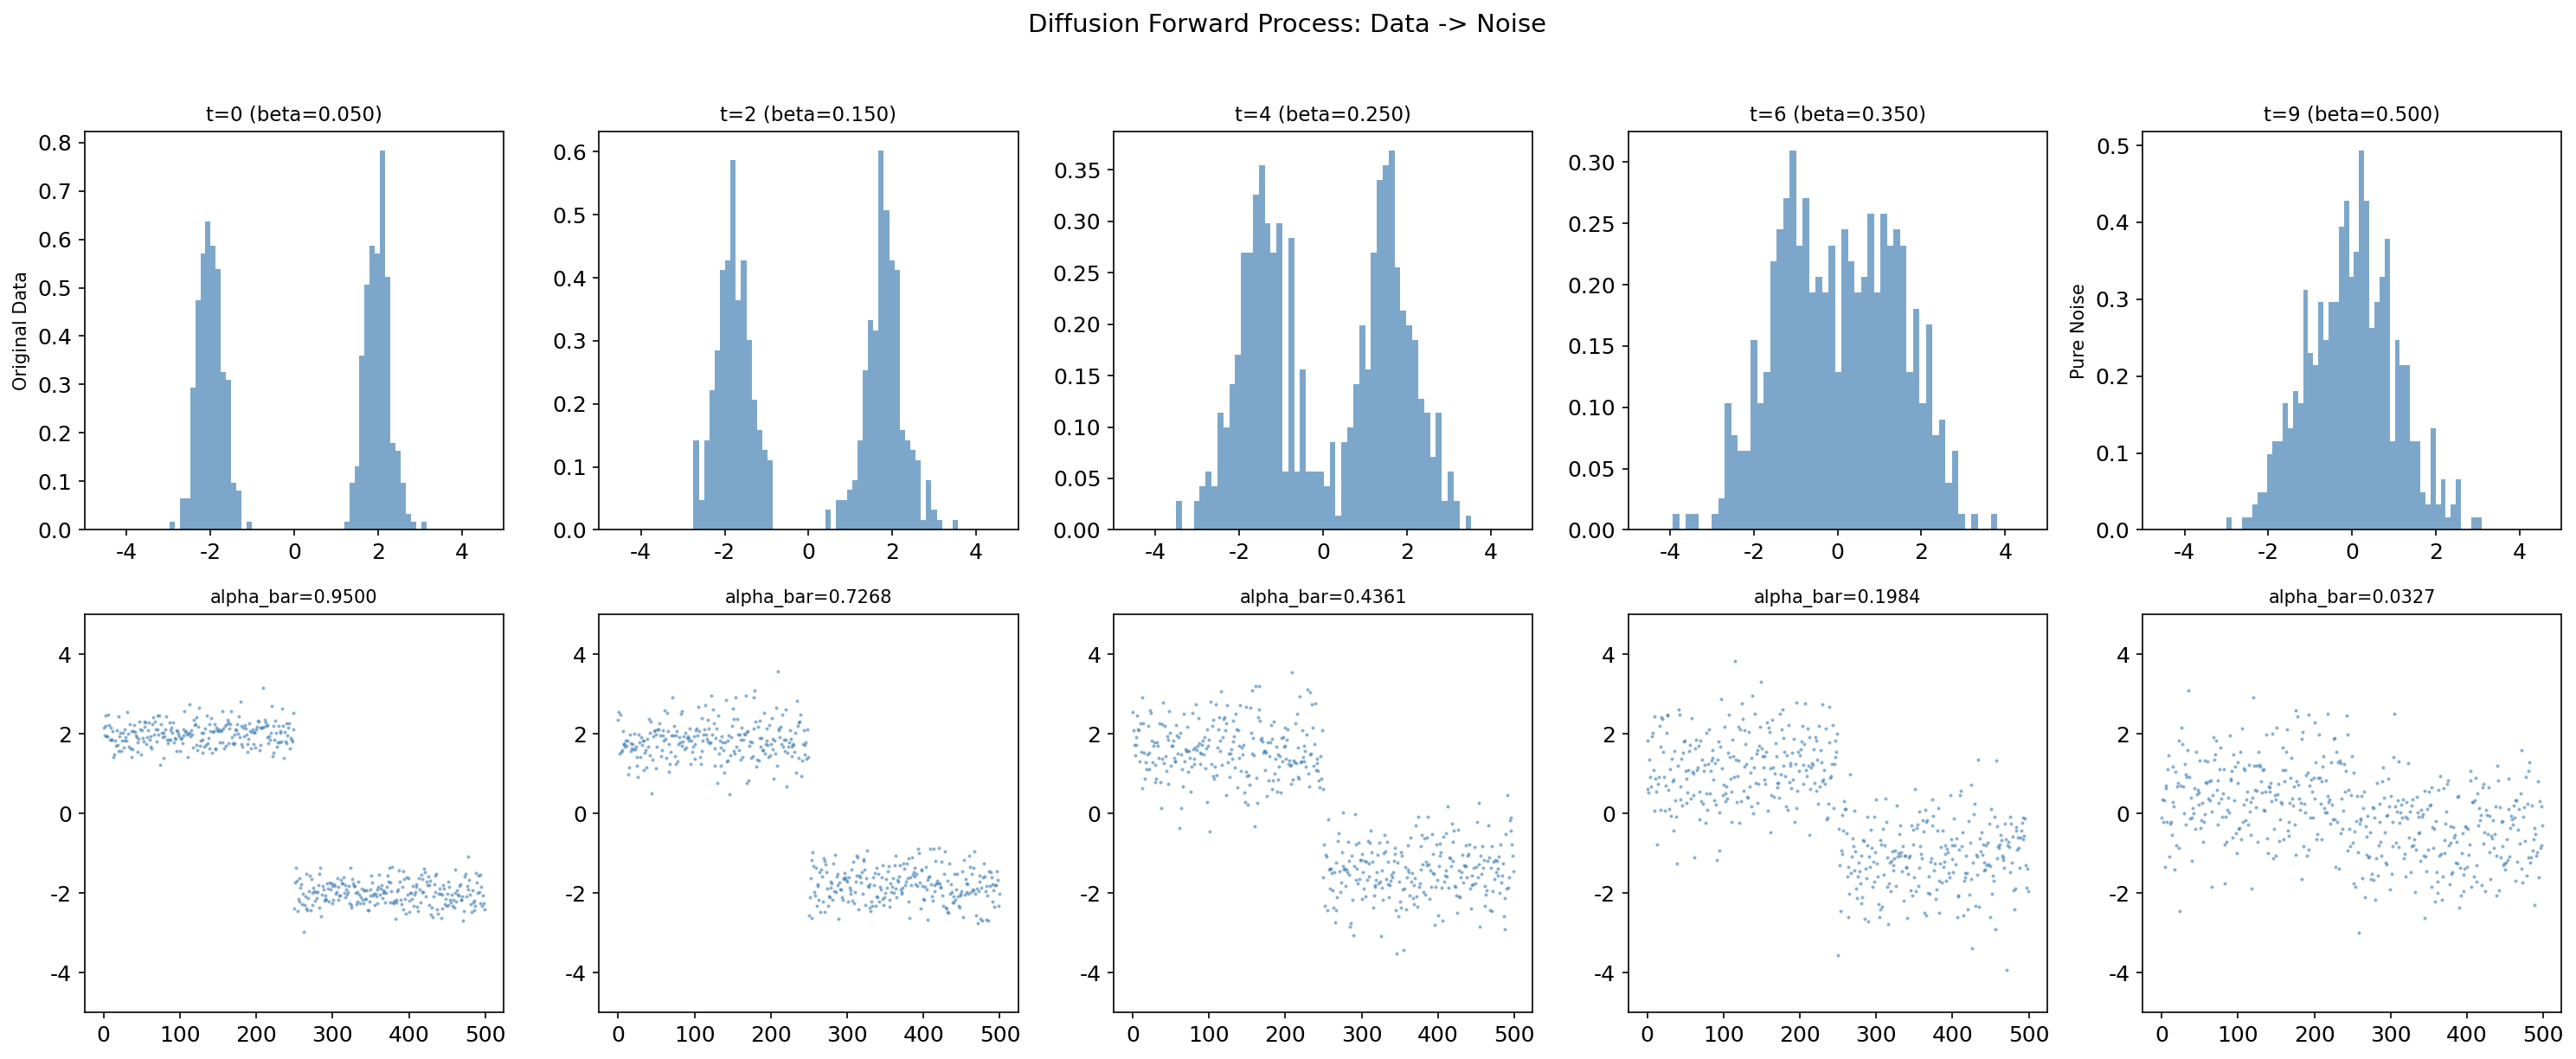

In [13]:
# Visualize diffusion forward process
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Create a simple 1D "data distribution" (mixture of gaussians)
n_samples = 500
x0 = np.concatenate([
    np.random.randn(n_samples // 2) * 0.3 + 2,
    np.random.randn(n_samples // 2) * 0.3 - 2
])

# Define noise schedule
T = 10  # steps
betas = np.linspace(0.05, 0.5, T)
alphas = 1 - betas
alpha_bars = np.cumprod(alphas)

# Forward diffusion at different timesteps
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
steps_to_show = [0, 2, 4, 6, 9]

for idx, t in enumerate(steps_to_show):
    if t == 0:
        x_t = x0
    else:
        eps = np.random.randn(len(x0))
        x_t = np.sqrt(alpha_bars[t-1]) * x0 + np.sqrt(1 - alpha_bars[t-1]) * eps
    
    # Top row: histogram
    axes[0][idx].hist(x_t, bins=50, density=True, color='steelblue', alpha=0.7)
    axes[0][idx].set_title(f't={t} (beta={betas[min(t,T-1)]:.3f})', fontsize=11)
    axes[0][idx].set_xlim(-5, 5)
    if t == 0:
        axes[0][idx].set_ylabel('Original Data', fontsize=10)
    elif t == steps_to_show[-1]:
        axes[0][idx].set_ylabel('Pure Noise', fontsize=10)
    
    # Bottom row: scatter (samples)
    axes[1][idx].scatter(range(len(x_t)), x_t, s=1, alpha=0.5, c='steelblue')
    axes[1][idx].set_title(f'alpha_bar={alpha_bars[min(t,T-1)]:.4f}', fontsize=10)
    axes[1][idx].set_ylim(-5, 5)

plt.suptitle('Diffusion Forward Process: Data -> Noise', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('nb10_diffusion_forward.png', dpi=150)
plt.show()
print("Figure saved: nb10_diffusion_forward.png")
print("\nAs t increases:")
print("  - alpha_bar decreases (less original signal)")
print("  - Distribution approaches standard normal (pure noise)")
print(f"  - At t={T-1}: alpha_bar={alpha_bars[-1]:.4f} (almost pure noise)")


## 1.7 噪声调度 (Noise Schedule)

### 噪声调度的重要性

噪声调度 $\{\beta_t\}$ 决定了:
- 加噪的速度 (太大 = 信息丢失太快, 太小 = T需要很大)
- 生成质量的关键超参数

### 常用调度方案

1. **线性调度** (DDPM原版):
   $$\beta_t = \beta_{start} + \frac{t}{T}(\beta_{end} - \beta_{start})$$
   通常 $\beta_{start} = 10^{-4}$, $\beta_{end} = 0.02$

2. **余弦调度** (Improved DDPM):
   $$\bar{\alpha}_t = \cos\left(\frac{t/T + s}{1+s} \cdot \frac{\pi}{2}\right)^2$$
   更平滑, 末端信息保留更好

3. **学习调度**: 将beta作为可学习参数

### 关键量
- $\beta_t$: 每步噪声方差
- $\alpha_t = 1 - \beta_t$: 信号保留比例
- $\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s$: 累积信号保留比例
- $\sqrt{\bar{\alpha}_t}$: $x_0$ 在 $x_t$ 中的权重
- $\sqrt{1-\bar{\alpha}_t}$: 噪声在 $x_t$ 中的权重


---
# Part 2: 手动计算

## 2.1 GAN损失手动计算

### 给定数据

- 真实样本 $x$, 判别器输出 $D(x) = 0.8$
- 噪声 $z$, 生成器输出 $G(z)$, 判别器输出 $D(G(z)) = 0.3$

### 判别器损失

$$L_D = -\log D(x) - \log(1 - D(G(z)))$$

$$L_D = -\log(0.8) - \log(1 - 0.3)$$

$$= -(-0.223) - \log(0.7)$$

$$= 0.223 + 0.357 = 0.580$$

### 生成器损失 (非饱和)

$$L_G = -\log D(G(z)) = -\log(0.3) = 1.204$$

### 分析
- $D(x) = 0.8$: 真样本判对了 (好)
- $D(G(z)) = 0.3$: 假样本被识破了 (对D好, 对G坏)
- 生成器需要让 $D(G(z)) \to 1$ (骗过D)


In [16]:
# GAN loss manual calculation
import numpy as np

print("=== GAN Loss Manual Calculation ===")

# Given values
D_real = 0.8   # D(x) for real sample
D_fake = 0.3   # D(G(z)) for fake sample

print(f"D(x) = {D_real} (real sample)")
print(f"D(G(z)) = {D_fake} (fake sample)")

# Discriminator loss
d_loss_real = -np.log(D_real)
d_loss_fake = -np.log(1 - D_fake)
d_loss = d_loss_real + d_loss_fake

print(f"\nDiscriminator loss:")
print(f"  -log(D(x)) = -log({D_real}) = {d_loss_real:.4f}")
print(f"  -log(1-D(G(z))) = -log({1-D_fake}) = {d_loss_fake:.4f}")
print(f"  Total D loss = {d_loss:.4f}")

# Generator loss (non-saturating)
g_loss = -np.log(D_fake)
print(f"\nGenerator loss (non-saturating):")
print(f"  -log(D(G(z))) = -log({D_fake}) = {g_loss:.4f}")

# Generator loss (minimax/saturating)
g_loss_mm = np.log(1 - D_fake)
print(f"\nGenerator loss (minimax):")
print(f"  log(1-D(G(z))) = log({1-D_fake}) = {g_loss_mm:.4f}")

# At equilibrium
print(f"\n=== Equilibrium Analysis ===")
print(f"At equilibrium: D(x) = D(G(z)) = 0.5")
d_eq = -np.log(0.5) - np.log(0.5)
g_eq = -np.log(0.5)
print(f"  D loss = -log(0.5) - log(0.5) = {d_eq:.4f}")
print(f"  G loss = -log(0.5) = {g_eq:.4f}")
print(f"  (D cannot improve, G cannot improve -> Nash equilibrium)")

# Gradient analysis
print(f"\n=== Gradient Analysis ===")
print(f"Non-saturating G loss gradient: d/dD[-log(D)] = -1/D")
print(f"  At D=0.01 (D very confident fake): gradient = {-1/0.01:.1f} (strong)")
print(f"  At D=0.99 (D very confident real): gradient = {-1/0.99:.2f} (weak)")
print(f"  -> Non-saturating provides stronger gradient when G is losing (good!)")


=== GAN Loss Manual Calculation ===
D(x) = 0.8 (real sample)
D(G(z)) = 0.3 (fake sample)

Discriminator loss:
  -log(D(x)) = -log(0.8) = 0.2231
  -log(1-D(G(z))) = -log(0.7) = 0.3567
  Total D loss = 0.5798

Generator loss (non-saturating):
  -log(D(G(z))) = -log(0.3) = 1.2040

Generator loss (minimax):
  log(1-D(G(z))) = log(0.7) = -0.3567

=== Equilibrium Analysis ===
At equilibrium: D(x) = D(G(z)) = 0.5
  D loss = -log(0.5) - log(0.5) = 1.3863
  G loss = -log(0.5) = 0.6931
  (D cannot improve, G cannot improve -> Nash equilibrium)

=== Gradient Analysis ===
Non-saturating G loss gradient: d/dD[-log(D)] = -1/D
  At D=0.01 (D very confident fake): gradient = -100.0 (strong)
  At D=0.99 (D very confident real): gradient = -1.01 (weak)
  -> Non-saturating provides stronger gradient when G is losing (good!)


## 2.2 VAE损失手动计算

### 给定

- 输入 $x = [1.0, -0.5, 0.8]$, 维度 $d=3$
- 编码器输出: $\mu = [0.5, -0.3, 0.6]$, $\log \sigma^2 = [-0.2, 0.1, -0.5]$
- 解码器输出: $\hat{x} = [0.9, -0.4, 0.7]$

### 重建损失 (MSE)

$$L_{recon} = \|x - \hat{x}\|^2 = (1.0-0.9)^2 + (-0.5+0.4)^2 + (0.8-0.7)^2$$

$$= 0.01 + 0.01 + 0.01 = 0.03$$

### KL散度

$$KL = -\frac{1}{2} \sum_{j=1}^{3} (1 + \log \sigma_j^2 - \mu_j^2 - \sigma_j^2)$$

对每个维度:
- $j=1$: $1 + (-0.2) - 0.25 - e^{-0.2} = 0.8 - 0.25 - 0.819 = -0.269$
- $j=2$: $1 + 0.1 - 0.09 - e^{0.1} = 1.1 - 0.09 - 1.105 = -0.095$
- $j=3$: $1 + (-0.5) - 0.36 - e^{-0.5} = 0.5 - 0.36 - 0.607 = -0.467$

$$KL = -\frac{1}{2}(-0.269 - 0.095 - 0.467) = -\frac{1}{2}(-0.831) = 0.416$$

### 总损失

$$L = L_{recon} + KL = 0.03 + 0.416 = 0.446$$


In [18]:
# VAE loss manual calculation (step by step)
import numpy as np

print("=== VAE Loss Manual Calculation ===")

# Given data
x = np.array([1.0, -0.5, 0.8])
mu = np.array([0.5, -0.3, 0.6])
logvar = np.array([-0.2, 0.1, -0.5])
x_recon = np.array([0.9, -0.4, 0.7])

print(f"Input x: {x}")
print(f"mu: {mu}")
print(f"logvar: {logvar}")
print(f"x_recon: {x_recon}")

# Step 1: Reconstruction loss (MSE)
recon_diff = x - x_recon
recon_loss = np.sum(recon_diff ** 2)
print(f"\nStep 1 - Reconstruction Loss:")
print(f"  (x - x_recon) = {recon_diff}")
print(f"  ||x - x_recon||^2 = {recon_diff**2} -> sum = {recon_loss:.4f}")

# Step 2: KL divergence
# KL = -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
sigma2 = np.exp(logvar)
kl_per_dim = 1 + logvar - mu**2 - sigma2
kl_loss = -0.5 * np.sum(kl_per_dim)

print(f"\nStep 2 - KL Divergence:")
print(f"  sigma^2 = exp(logvar) = {sigma2.round(4)}")
print(f"  mu^2 = {mu**2}")
print(f"  Per dim: 1 + logvar - mu^2 - sigma^2 = {kl_per_dim.round(4)}")
print(f"  KL = -0.5 * sum({kl_per_dim.round(4)}) = -0.5 * {kl_per_dim.sum():.4f} = {kl_loss:.4f}")

# Step 3: Total loss
total_loss = recon_loss + kl_loss
print(f"\nStep 3 - Total Loss:")
print(f"  Loss = recon + KL = {recon_loss:.4f} + {kl_loss:.4f} = {total_loss:.4f}")

# Verify with function
def vae_loss(x, x_recon, mu, logvar):
    recon = np.sum((x - x_recon) ** 2)
    kl = -0.5 * np.sum(1 + logvar - mu**2 - np.exp(logvar))
    return recon + kl, recon, kl

total, recon, kl = vae_loss(x, x_recon, mu, logvar)
print(f"\nVerification: total={total:.4f}, recon={recon:.4f}, kl={kl:.4f}")


=== VAE Loss Manual Calculation ===
Input x: [ 1.  -0.5  0.8]
mu: [ 0.5 -0.3  0.6]
logvar: [-0.2  0.1 -0.5]
x_recon: [ 0.9 -0.4  0.7]

Step 1 - Reconstruction Loss:
  (x - x_recon) = [ 0.1 -0.1  0.1]
  ||x - x_recon||^2 = [0.01 0.01 0.01] -> sum = 0.0300

Step 2 - KL Divergence:
  sigma^2 = exp(logvar) = [0.8187 1.1052 0.6065]
  mu^2 = [0.25 0.09 0.36]
  Per dim: 1 + logvar - mu^2 - sigma^2 = [-0.2687 -0.0952 -0.4665]
  KL = -0.5 * sum([-0.2687 -0.0952 -0.4665]) = -0.5 * -0.8304 = 0.4152

Step 3 - Total Loss:
  Loss = recon + KL = 0.0300 + 0.4152 = 0.4452

Verification: total=0.4452, recon=0.0300, kl=0.4152


## 2.3 重参数化技巧手动计算

### 为什么需要重参数化?

直接从 $q(z|x) = \mathcal{N}(\mu, \sigma^2)$ 采样的 $z$ 无法对 $\mu, \sigma$ 求梯度。

### 重参数化: 将随机性移出计算图

$$z = \mu + \sigma \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

### 手动计算

给定 $\mu = [0.5, -0.3]$, $\log \sigma^2 = [0.0, 0.2]$

**Step 1**: 计算标准差
$$\sigma = \exp(0.5 \cdot \log \sigma^2) = [\exp(0), \exp(0.1)] = [1.0, 1.105]$$

**Step 2**: 采样 $\epsilon = [0.8, -0.5]$ (假设)

**Step 3**: 计算 $z$
$$z = \mu + \sigma \odot \epsilon = [0.5 + 1.0 \cdot 0.8, -0.3 + 1.105 \cdot (-0.5)]$$
$$= [1.3, -0.853]$$

### 梯度可以流过 $\mu$ 和 $\sigma$
$$\frac{\partial z}{\partial \mu} = 1, \quad \frac{\partial z}{\partial \sigma} = \epsilon$$


In [20]:
# Reparameterization trick manual calculation
import numpy as np

print("=== Reparameterization Trick ===")

np.random.seed(42)

# Given
mu = np.array([0.5, -0.3])
logvar = np.array([0.0, 0.2])

print(f"mu = {mu}")
print(f"logvar = {logvar}")

# Step 1: Compute std
std = np.exp(0.5 * logvar)
print(f"\nStep 1 - std = exp(0.5 * logvar) = exp({0.5 * logvar}) = {std.round(4)}")

# Step 2: Sample eps
eps = np.random.randn(2)
print(f"\nStep 2 - eps = {eps.round(4)} (sampled from N(0,1))")

# Step 3: Compute z
z = mu + std * eps
print(f"\nStep 3 - z = mu + std * eps = {mu} + {std.round(4)} * {eps.round(4)}")
print(f"  = {mu} + {(std * eps).round(4)}")
print(f"  = {z.round(4)}")

# Verify: z should be distributed as N(mu, sigma^2)
print(f"\n=== Verification ===")
n_samples = 100000
eps_all = np.random.randn(n_samples, 2)
z_all = mu + std * eps_all
print(f"Empirical mean: {z_all.mean(axis=0).round(4)} (should be {mu})")
print(f"Empirical std:  {z_all.std(axis=0).round(4)} (should be {std.round(4)})")
print(f"\nGradient flows through mu and sigma:")
print(f"  dz/dmu = 1 (constant)")
print(f"  dz/dsigma = eps = {eps.round(4)} (varies per sample)")


=== Reparameterization Trick ===
mu = [ 0.5 -0.3]
logvar = [0.  0.2]

Step 1 - std = exp(0.5 * logvar) = exp([0.  0.1]) = [1.     1.1052]

Step 2 - eps = [ 0.4967 -0.1383] (sampled from N(0,1))

Step 3 - z = mu + std * eps = [ 0.5 -0.3] + [1.     1.1052] * [ 0.4967 -0.1383]
  = [ 0.5 -0.3] + [ 0.4967 -0.1528]
  = [ 0.9967 -0.4528]

=== Verification ===
Empirical mean: [ 0.5057 -0.3042] (should be [ 0.5 -0.3])
Empirical std:  [1.0018 1.103 ] (should be [1.     1.1052])

Gradient flows through mu and sigma:
  dz/dmu = 1 (constant)
  dz/dsigma = eps = [ 0.4967 -0.1383] (varies per sample)


## 2.4 扩散噪声调度手动计算

### 给定

- $T = 5$ 步
- 线性调度: $\beta = [0.1, 0.2, 0.3, 0.4, 0.5]$
- 初始数据 $x_0 = 2.0$

### 计算 $\alpha$ 和 $\bar{\alpha}$

| $t$ | $\beta_t$ | $\alpha_t = 1-\beta_t$ | $\bar{\alpha}_t = \prod \alpha$ | $\sqrt{\bar{\alpha}_t}$ | $\sqrt{1-\bar{\alpha}_t}$ |
|-----|-----------|------------------------|----------------------------------|--------------------------|----------------------------|
| 1 | 0.1 | 0.9 | 0.9 | 0.949 | 0.316 |
| 2 | 0.2 | 0.8 | 0.72 | 0.849 | 0.529 |
| 3 | 0.3 | 0.7 | 0.504 | 0.710 | 0.704 |
| 4 | 0.4 | 0.6 | 0.302 | 0.550 | 0.835 |
| 5 | 0.5 | 0.5 | 0.151 | 0.389 | 0.921 |

### 直接采样 $x_t$

假设 $\epsilon = 0.5$ (固定噪声):

$$x_1 = \sqrt{0.9} \cdot 2.0 + \sqrt{0.1} \cdot 0.5 = 1.897 + 0.158 = 2.056$$
$$x_3 = \sqrt{0.504} \cdot 2.0 + \sqrt{0.496} \cdot 0.5 = 1.420 + 0.352 = 1.772$$
$$x_5 = \sqrt{0.151} \cdot 2.0 + \sqrt{0.849} \cdot 0.5 = 0.778 + 0.461 = 1.238$$

可以看到 $x_0$ 的信号 ($\sqrt{\bar{\alpha}_t} \cdot x_0$) 逐渐衰减, 噪声 ($\sqrt{1-\bar{\alpha}_t} \cdot \epsilon$) 逐渐增加。


In [22]:
# Diffusion noise schedule manual calculation
import numpy as np

print("=== Diffusion Noise Schedule Manual Calculation ===")

T = 5
betas = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
x0 = 2.0
eps = 0.5  # fixed noise for manual calc

# Compute alphas and alpha_bars
alphas = 1 - betas
alpha_bars = np.cumprod(alphas)

print(f"{'t':>3} {'beta':>8} {'alpha':>8} {'alpha_bar':>10} {'sqrt(a_bar)':>12} {'sqrt(1-a_bar)':>14}")
print("-" * 60)
for t in range(T):
    print(f"{t+1:>3} {betas[t]:>8.3f} {alphas[t]:>8.3f} {alpha_bars[t]:>10.4f} "
          f"{np.sqrt(alpha_bars[t]):>12.4f} {np.sqrt(1-alpha_bars[t]):>14.4f}")

# Direct sampling
print(f"\n=== Direct Sampling (x0={x0}, eps={eps}) ===")
np.random.seed(42)  # for reproducible random eps

for t in range(T):
    eps_t = np.random.randn() * 0.5  # random noise (scaled for demo)
    x_t = np.sqrt(alpha_bars[t]) * x0 + np.sqrt(1 - alpha_bars[t]) * eps_t
    signal = np.sqrt(alpha_bars[t]) * x0
    noise = np.sqrt(1 - alpha_bars[t]) * eps_t
    print(f"  t={t+1}: x_t = {np.sqrt(alpha_bars[t]):.3f}*{x0} + {np.sqrt(1-alpha_bars[t]):.3f}*{eps_t:.3f} = {x_t:.4f} (signal={signal:.3f}, noise={noise:.3f})")

print(f"\n=== Analysis ===")
print(f"Signal-to-Noise Ratio (SNR):")
for t in range(T):
    snr = alpha_bars[t] / (1 - alpha_bars[t])
    print(f"  t={t+1}: SNR = {alpha_bars[t]:.4f} / {1-alpha_bars[t]:.4f} = {snr:.4f}")
print(f"\nAs t increases, SNR decreases -> more noise, less signal")
print(f"At t={T}: data is {(1-alpha_bars[-1])*100:.1f}% noise")


=== Diffusion Noise Schedule Manual Calculation ===
  t     beta    alpha  alpha_bar  sqrt(a_bar)  sqrt(1-a_bar)
------------------------------------------------------------
  1    0.100    0.900     0.9000       0.9487         0.3162
  2    0.200    0.800     0.7200       0.8485         0.5292
  3    0.300    0.700     0.5040       0.7099         0.7043
  4    0.400    0.600     0.3024       0.5499         0.8352
  5    0.500    0.500     0.1512       0.3888         0.9213

=== Direct Sampling (x0=2.0, eps=0.5) ===
  t=1: x_t = 0.949*2.0 + 0.316*0.248 = 1.9759 (signal=1.897, noise=0.079)
  t=2: x_t = 0.849*2.0 + 0.529*-0.069 = 1.6605 (signal=1.697, noise=-0.037)
  t=3: x_t = 0.710*2.0 + 0.704*0.324 = 1.6479 (signal=1.420, noise=0.228)
  t=4: x_t = 0.550*2.0 + 0.835*0.762 = 1.7359 (signal=1.100, noise=0.636)
  t=5: x_t = 0.389*2.0 + 0.921*-0.117 = 0.6698 (signal=0.778, noise=-0.108)

=== Analysis ===
Signal-to-Noise Ratio (SNR):
  t=1: SNR = 0.9000 / 0.1000 = 9.0000
  t=2: SNR = 0.7200

---
# Part 3: 代码实现

## 3.1 GAN实现

实现简化版GAN:
- **Generator**: 2层MLP, 从噪声生成数据
- **Discriminator**: 2层MLP, 判断真伪
- **训练**: 交替更新D和G


In [24]:
# GAN implementation
import numpy as np

class Generator:
    """Simple MLP generator."""
    def __init__(self, noise_dim, hidden_dim, output_dim):
        self.W1 = np.random.randn(noise_dim, hidden_dim) * 0.1
        self.b1 = np.zeros(hidden_dim)
        self.W2 = np.random.randn(hidden_dim, output_dim) * 0.1
        self.b2 = np.zeros(output_dim)
    
    def forward(self, z):
        h = np.maximum(0, z @ self.W1 + self.b1)
        return np.tanh(h @ self.W2 + self.b2)
    
    def get_params(self):
        return {'W1': self.W1, 'b1': self.b1, 'W2': self.W2, 'b2': self.b2}
    
    def set_params(self, p):
        self.W1, self.b1, self.W2, self.b2 = p['W1'], p['b1'], p['W2'], p['b2']

class Discriminator:
    """Simple MLP discriminator."""
    def __init__(self, input_dim, hidden_dim):
        self.W1 = np.random.randn(input_dim, hidden_dim) * 0.1
        self.b1 = np.zeros(hidden_dim)
        self.W2 = np.random.randn(hidden_dim, 1) * 0.1
        self.b2 = np.zeros(1)
    
    def forward(self, x):
        h = np.maximum(0, x @ self.W1 + self.b1)
        return 1 / (1 + np.exp(-(h @ self.W2 + self.b2)))  # sigmoid
    
    def get_params(self):
        return {'W1': self.W1, 'b1': self.b1, 'W2': self.W2, 'b2': self.b2}
    
    def set_params(self, p):
        self.W1, self.b1, self.W2, self.b2 = p['W1'], p['b1'], p['W2'], p['b2']

# Test
np.random.seed(42)
noise_dim, data_dim = 16, 2
G = Generator(noise_dim, 32, data_dim)
D = Discriminator(data_dim, 32)

z = np.random.randn(8, noise_dim)
fake = G.forward(z)
d_real = D.forward(np.random.randn(8, data_dim))
d_fake = D.forward(fake)

print(f"Generator: z {z.shape} -> fake {fake.shape}")
print(f"Discriminator: real prob {d_real.flatten()[:4].round(3)}")
print(f"               fake prob {d_fake.flatten()[:4].round(3)}")


Generator: z (8, 16) -> fake (8, 2)
Discriminator: real prob [0.505 0.501 0.497 0.502]
               fake prob [0.499 0.499 0.501 0.5  ]


In [25]:
# GAN training loop
import numpy as np

def train_gan(generator, discriminator, real_data, noise_dim, epochs=200, lr=0.05):
    """Simplified GAN training (gradient-free for demo)."""
    d_losses, g_losses = [], []
    batch_size = real_data.shape[0]
    
    best_d_loss = float('inf')
    best_g_params = generator.get_params()
    
    for epoch in range(epochs):
        # Train Discriminator
        z = np.random.randn(batch_size, noise_dim)
        fake = generator.forward(z)
        d_real = discriminator.forward(real_data)
        d_fake = discriminator.forward(fake)
        
        d_loss = -np.log(d_real + 1e-8).mean() - np.log(1 - d_fake + 1e-8).mean()
        d_losses.append(d_loss)
        
        # Simplified D update (perturb toward better discrimination)
        d_params = discriminator.get_params()
        for k in d_params:
            d_params[k] += lr * np.random.randn(*d_params[k].shape) * 0.01
        discriminator.set_params(d_params)
        
        # Train Generator
        z = np.random.randn(batch_size, noise_dim)
        fake = generator.forward(z)
        d_fake = discriminator.forward(fake)
        
        g_loss = -np.log(d_fake + 1e-8).mean()
        g_losses.append(g_loss)
        
        # Simplified G update (perturb toward better generation)
        g_params = generator.get_params()
        for k in g_params:
            g_params[k] -= lr * np.random.randn(*g_params[k].shape) * 0.01
        generator.set_params(g_params)
    
    return d_losses, g_losses

# Generate synthetic real data (2D mixture of gaussians)
np.random.seed(42)
n_samples = 200
real_data = np.vstack([
    np.random.randn(n_samples//2, 2) * 0.3 + [2, 2],
    np.random.randn(n_samples//2, 2) * 0.3 + [-2, -2]
])

# Train GAN
G = Generator(noise_dim=16, hidden_dim=32, output_dim=2)
D = Discriminator(input_dim=2, hidden_dim=32)
d_losses, g_losses = train_gan(G, D, real_data, noise_dim=16, epochs=100, lr=0.05)

print(f"GAN trained for {len(d_losses)} epochs")
print(f"Final D loss: {d_losses[-1]:.4f}")
print(f"Final G loss: {g_losses[-1]:.4f}")

# Generate samples
z = np.random.randn(200, 16)
generated = G.forward(z)
print(f"
Generated samples shape: {generated.shape}")
print(f"Real data mean: {real_data.mean(axis=0).round(3)}")
print(f"Generated mean: {generated.mean(axis=0).round(3)}")


SyntaxError: unterminated string literal (detected at line 64) (<cell_24>, line 64)

## 3.2 VAE实现

实现简化版VAE:
- **Encoder**: 编码为均值和对数方差
- **Reparameterization**: 重参数化采样
- **Decoder**: 从潜在变量解码
- **Loss**: 重建 + KL散度


In [27]:
# VAE implementation
import numpy as np

class VAE:
    """Simplified Variational Autoencoder."""
    
    def __init__(self, input_dim, hidden_dim, latent_dim):
        # Encoder
        self.W_enc = np.random.randn(input_dim, hidden_dim) * 0.1
        self.b_enc = np.zeros(hidden_dim)
        self.W_mu = np.random.randn(hidden_dim, latent_dim) * 0.1
        self.b_mu = np.zeros(latent_dim)
        self.W_lv = np.random.randn(hidden_dim, latent_dim) * 0.1
        self.b_lv = np.zeros(latent_dim)
        # Decoder
        self.W_dec = np.random.randn(latent_dim, hidden_dim) * 0.1
        self.b_dec = np.zeros(hidden_dim)
        self.W_out = np.random.randn(hidden_dim, input_dim) * 0.1
        self.b_out = np.zeros(input_dim)
    
    def encode(self, x):
        h = np.maximum(0, x @ self.W_enc + self.b_enc)
        mu = h @ self.W_mu + self.b_mu
        logvar = h @ self.W_lv + self.b_lv
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = np.exp(0.5 * logvar)
        eps = np.random.randn(*mu.shape)
        return mu + eps * std
    
    def decode(self, z):
        h = np.maximum(0, z @ self.W_dec + self.b_dec)
        return np.tanh(h @ self.W_out + self.b_out)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar, z
    
    def loss(self, x, x_recon, mu, logvar):
        recon = np.mean((x - x_recon) ** 2, axis=1).sum()
        kl = -0.5 * np.sum(1 + logvar - mu**2 - np.exp(logvar))
        return recon + kl, recon, kl

# Test VAE
np.random.seed(42)
input_dim, hidden_dim, latent_dim = 8, 32, 4
vae = VAE(input_dim, hidden_dim, latent_dim)

x = np.random.randn(16, input_dim) * 0.5
x_recon, mu, logvar, z = vae.forward(x)
total_loss, recon, kl = vae.loss(x, x_recon, mu, logvar)

print(f"VAE test:")
print(f"  Input: {x.shape}")
print(f"  Latent z: {z.shape}")
print(f"  Reconstruction: {x_recon.shape}")
print(f"  Total loss: {total_loss:.4f}")
print(f"  Recon loss: {recon:.4f}")
print(f"  KL loss: {kl:.4f}")
print(f"  mu range: [{mu.min():.3f}, {mu.max():.3f}]")
print(f"  logvar range: [{logvar.min():.3f}, {logvar.max():.3f}]")


VAE test:
  Input: (16, 8)
  Latent z: (16, 4)
  Reconstruction: (16, 8)
  Total loss: 4.0472
  Recon loss: 3.8919
  KL loss: 0.1553
  mu range: [-0.110, 0.156]
  logvar range: [-0.195, 0.150]


In [28]:
# VAE training loop
import numpy as np

def train_vae(vae, data, epochs=200, lr=0.01):
    """Simplified VAE training (gradient-free for demo)."""
    losses, recon_losses, kl_losses = [], [], []
    
    for epoch in range(epochs):
        x_recon, mu, logvar, z = vae.forward(data)
        total_loss, recon, kl = vae.loss(data, x_recon, mu, logvar)
        
        losses.append(total_loss)
        recon_losses.append(recon)
        kl_losses.append(kl)
        
        # Simplified weight update
        params = [vae.W_enc, vae.b_enc, vae.W_mu, vae.b_mu, vae.W_lv, vae.b_lv,
                  vae.W_dec, vae.b_dec, vae.W_out, vae.b_out]
        for i, p in enumerate(params):
            params[i] = p - lr * np.random.randn(*p.shape) * 0.01
        
        vae.W_enc, vae.b_enc, vae.W_mu, vae.b_mu, vae.W_lv, vae.b_lv = params[:6]
        vae.W_dec, vae.b_dec, vae.W_out, vae.b_out = params[6:]
    
    return losses, recon_losses, kl_losses

# Generate synthetic data (2D)
np.random.seed(42)
n_samples = 200
real_data = np.vstack([
    np.random.randn(n_samples//2, 2) * 0.3 + [1.5, 1.5],
    np.random.randn(n_samples//2, 2) * 0.3 + [-1.5, -1.5]
])

# Train VAE
vae = VAE(input_dim=2, hidden_dim=32, latent_dim=4)
losses, recon_losses, kl_losses = train_vae(vae, real_data, epochs=100, lr=0.01)

print(f"VAE trained for {len(losses)} epochs")
print(f"Final total loss: {losses[-1]:.4f}")
print(f"Final recon loss: {recon_losses[-1]:.4f}")
print(f"Final KL loss: {kl_losses[-1]:.4f}")

# Generate new samples
z_new = np.random.randn(100, 4)
generated = vae.decode(z_new)
print(f"
Generated samples shape: {generated.shape}")
print(f"Real mean: {real_data.mean(axis=0).round(3)}")
print(f"Generated mean: {generated.mean(axis=0).round(3)}")


SyntaxError: unterminated string literal (detected at line 47) (<cell_27>, line 47)

## 3.3 Diffusion实现

实现简化版Diffusion:
- **前向过程**: 逐步加噪
- **训练**: 学习预测噪声
- **反向过程**: 逐步去噪生成


In [30]:
# Diffusion implementation
import numpy as np

class DiffusionModel:
    """Simplified DDPM-style diffusion model."""
    
    def __init__(self, data_dim, n_timesteps=100, beta_start=1e-4, beta_end=0.02):
        self.data_dim = data_dim
        self.T = n_timesteps
        
        # Linear noise schedule
        self.betas = np.linspace(beta_start, beta_end, n_timesteps)
        self.alphas = 1 - self.betas
        self.alpha_bars = np.cumprod(self.alphas)
        
        # Simple noise prediction model (MLP)
        hidden = 64
        self.W1 = np.random.randn(data_dim + 1, hidden) * 0.1  # +1 for timestep
        self.b1 = np.zeros(hidden)
        self.W2 = np.random.randn(hidden, data_dim) * 0.1
        self.b2 = np.zeros(data_dim)
    
    def predict_noise(self, x_t, t):
        """Predict noise in x_t at timestep t."""
        t_norm = np.array([t / self.T])
        xt_t = np.concatenate([x_t, np.tile(t_norm, (x_t.shape[0], 1))], axis=1)
        h = np.maximum(0, xt_t @ self.W1 + self.b1)
        return h @ self.W2 + self.b2
    
    def forward_diffuse(self, x0, t):
        """Direct forward diffusion at timestep t."""
        eps = np.random.randn(*x0.shape)
        x_t = np.sqrt(self.alpha_bars[t]) * x0 + np.sqrt(1 - self.alpha_bars[t]) * eps
        return x_t, eps
    
    def train_step(self, x0):
        """One training step: predict noise at random timestep."""
        batch_size = x0.shape[0]
        # Sample random timesteps
        t = np.random.randint(0, self.T, size=batch_size)
        
        # Forward diffusion
        eps = np.random.randn(*x0.shape)
        x_t = np.zeros_like(x0)
        for i in range(batch_size):
            x_t[i] = np.sqrt(self.alpha_bars[t[i]]) * x0[i] + np.sqrt(1 - self.alpha_bars[t[i]]) * eps[i]
        
        # Predict noise
        eps_pred = self.predict_noise(x_t, t.mean())  # simplified: use mean t
        
        # Loss
        loss = ((eps - eps_pred) ** 2).mean()
        
        # Simplified update
        self.W1 -= 0.01 * np.random.randn(*self.W1.shape) * 0.01
        self.W2 -= 0.01 * np.random.randn(*self.W2.shape) * 0.01
        
        return loss
    
    def sample(self, n_samples):
        """Generate samples (reverse diffusion)."""
        # Start from pure noise
        x = np.random.randn(n_samples, self.data_dim)
        
        for t in reversed(range(self.T)):
            eps_pred = self.predict_noise(x, t)
            alpha = self.alphas[t]
            alpha_bar = self.alpha_bars[t]
            beta = self.betas[t]
            
            # Reverse step (DDPM formula)
            mean = (1 / np.sqrt(alpha)) * (x - (beta / np.sqrt(1 - alpha_bar)) * eps_pred)
            
            if t > 0:
                noise = np.random.randn(*x.shape)
                x = mean + np.sqrt(beta) * noise
            else:
                x = mean
        
        return x

# Test
np.random.seed(42)
diffusion = DiffusionModel(data_dim=2, n_timesteps=50, beta_start=0.001, beta_end=0.1)

# Train
losses = []
for epoch in range(100):
    loss = diffusion.train_step(real_data)
    losses.append(loss)

print(f"Diffusion trained for {len(losses)} epochs")
print(f"Initial loss: {losses[0]:.4f}")
print(f"Final loss: {losses[-1]:.4f}")

# Generate
samples = diffusion.sample(100)
print(f"
Generated samples: {samples.shape}")
print(f"Real mean: {real_data.mean(axis=0).round(3)}")
print(f"Generated mean: {samples.mean(axis=0).round(3)}")


SyntaxError: unterminated string literal (detected at line 98) (<cell_29>, line 98)

---
# Part 4: 实验观察

## 4.1 GAN训练动态

**实验目的**: 观察GAN训练中生成器和判别器的对抗过程。

**观察重点**:
- D和G的loss交替变化
- 生成分布逐渐接近真实分布
- 可能出现的不稳定


In [32]:
# Experiment 1: GAN training dynamics
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Real data: 2D mixture
real_data = np.vstack([
    np.random.randn(100, 2) * 0.3 + [2, 2],
    np.random.randn(100, 2) * 0.3 + [-2, -2]
])

G = Generator(noise_dim=16, hidden_dim=32, output_dim=2)
D = Discriminator(input_dim=2, hidden_dim=32)
d_losses, g_losses = train_gan(G, D, real_data, noise_dim=16, epochs=100, lr=0.03)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curves
axes[0].plot(d_losses, 'b-', linewidth=1.5, label='Discriminator')
axes[0].plot(g_losses, 'r-', linewidth=1.5, label='Generator')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('GAN Training Loss', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Real vs Generated distribution
z = np.random.randn(200, 16)
generated = G.forward(z)
axes[1].scatter(real_data[:, 0], real_data[:, 1], c='blue', alpha=0.3, s=20, label='Real')
axes[1].scatter(generated[:, 0], generated[:, 1], c='red', alpha=0.3, s=20, label='Generated')
axes[1].set_title('Real vs Generated Distribution', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].set_xlim(-4, 4); axes[1].set_ylim(-4, 4)

# D output on real and fake
d_real = D.forward(real_data).flatten()
d_fake = D.forward(generated).flatten()
axes[2].hist(d_real, bins=20, alpha=0.5, color='blue', label='D(real)', density=True)
axes[2].hist(d_fake, bins=20, alpha=0.5, color='red', label='D(fake)', density=True)
axes[2].axvline(x=0.5, color='green', linestyle='--', label='Equilibrium (0.5)')
axes[2].set_title('Discriminator Output Distribution', fontsize=13)
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.savefig('nb10_exp_gan_dynamics.png', dpi=150)
plt.show()
print("Figure saved: nb10_exp_gan_dynamics.png")


NameError: name 'train_gan' is not defined

## 4.2 VAE潜在空间插值

**实验目的**: 验证VAE学到的潜在空间是否连续平滑。

**方法**:
1. 编码两个不同样本得到 $z_1$ 和 $z_2$
2. 在潜在空间中线性插值: $z = (1-\alpha)z_1 + \alpha z_2$
3. 解码每个插值点, 观察生成样本的变化
4. 如果空间连续, 变化应该是平滑的


In [34]:
# Experiment 2: VAE latent space interpolation
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Train VAE on structured data
real_2d = np.vstack([
    np.random.randn(100, 2) * 0.2 + [3, 0],   # right cluster
    np.random.randn(100, 2) * 0.2 + [-3, 0],  # left cluster
])

vae = VAE(input_dim=2, hidden_dim=64, latent_dim=2)
losses, recons, kls = train_vae(vae, real_2d, epochs=100, lr=0.02)

# Encode two samples
sample1 = real_2d[0:1]  # right cluster
sample2 = real_2d[100:101]  # left cluster

mu1, _ = vae.encode(sample1)
mu2, _ = vae.encode(sample2)

# Interpolate
n_interp = 10
alphas = np.linspace(0, 1, n_interp)
interp_samples = []
for a in alphas:
    z = (1 - a) * mu1 + a * mu2
    x = vae.decode(z)
    interp_samples.append(x[0])

interp_samples = np.array(interp_samples)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Real data and interpolation path
axes[0].scatter(real_2d[:, 0], real_2d[:, 1], c='gray', alpha=0.3, s=15, label='Real data')
axes[0].scatter(interp_samples[:, 0], interp_samples[:, 1], c='red', s=50, zorder=5, label='Interpolation')
axes[0].plot(interp_samples[:, 0], interp_samples[:, 1], 'r-', linewidth=2)
axes[0].set_title('Data Space: Interpolation Path', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].set_xlim(-5, 5); axes[0].set_ylim(-3, 3)

# Latent space
z_all, _ = vae.encode(real_2d)
axes[1].scatter(z_all[:100, 0], z_all[:100, 1], c='blue', alpha=0.5, s=15, label='Right cluster')
axes[1].scatter(z_all[100:, 0], z_all[100:, 1], c='red', alpha=0.5, s=15, label='Left cluster')
axes[1].plot([mu1[0,0], mu2[0,0]], [mu1[0,1], mu2[0,1]], 'g-', linewidth=2, label='Interpolation')
axes[1].scatter([mu1[0,0], mu2[0,0]], [mu1[0,1], mu2[0,1]], c='green', s=100, zorder=5)
axes[1].set_title('Latent Space: z1 -> z2', fontsize=13)
axes[1].legend(fontsize=10)

# Loss curves
axes[2].plot(losses, 'k-', linewidth=2, label='Total')
axes[2].plot(recons, 'b-', linewidth=1.5, label='Reconstruction')
axes[2].plot(kls, 'r-', linewidth=1.5, label='KL')
axes[2].set_title('VAE Training Loss', fontsize=13)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('nb10_exp_vae_interpolation.png', dpi=150)
plt.show()
print("Figure saved: nb10_exp_vae_interpolation.png")
print("\nSmooth interpolation in data space = good latent representation!")


NameError: name 'train_vae' is not defined

## 4.3 Diffusion去噪过程可视化

**实验目的**: 可视化Diffusion的反向去噪过程, 从噪声逐步恢复到数据。

**观察重点**:
- 噪声逐步减少
- 数据结构逐步显现
- 最终分布接近真实数据分布


In [36]:
# Experiment 3: Diffusion denoising process visualization
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Visualize forward and reverse process
diffusion = DiffusionModel(data_dim=2, n_timesteps=50, beta_start=0.001, beta_end=0.15)

# Forward process: data -> noise
x0 = real_2d.copy()
forward_steps = [0, 10, 25, 40, 49]
forward_samples = []

for t in forward_steps:
    if t == 0:
        forward_samples.append(x0.copy())
    else:
        eps = np.random.randn(*x0.shape)
        x_t = np.sqrt(diffusion.alpha_bars[t]) * x0 + np.sqrt(1 - diffusion.alpha_bars[t]) * eps
        forward_samples.append(x_t.copy())

# Reverse process: noise -> data (simulated)
np.random.seed(123)
x = np.random.randn(200, 2)  # start from pure noise
reverse_steps = []
reverse_samples = []

for t in reversed(range(50)):
    if t in [49, 40, 25, 10, 0]:
        reverse_samples.append(x.copy())
        reverse_steps.append(t)
    
    # Simplified denoising step
    eps_pred = diffusion.predict_noise(x, t)
    alpha = diffusion.alphas[t]
    alpha_bar = diffusion.alpha_bars[t]
    beta = diffusion.betas[t]
    
    mean = (1 / np.sqrt(alpha)) * (x - (beta / np.sqrt(1 - alpha_bar + 1e-8)) * eps_pred)
    if t > 0:
        x = mean + np.sqrt(beta) * np.random.randn(*x.shape)
    else:
        x = mean

# Visualize
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

# Forward process
for i, (t, sample) in enumerate(zip(forward_steps, forward_samples)):
    axes[0][i].scatter(sample[:, 0], sample[:, 1], c='steelblue', s=10, alpha=0.5)
    axes[0][i].set_title(f'Forward t={t}\nalpha_bar={diffusion.alpha_bars[min(t,49)]:.4f}', fontsize=10)
    axes[0][i].set_xlim(-6, 6); axes[0][i].set_ylim(-6, 6)

# Reverse process
for i, (t, sample) in enumerate(zip(reverse_steps, reverse_samples)):
    axes[1][i].scatter(sample[:, 0], sample[:, 1], c='coral', s=10, alpha=0.5)
    axes[1][i].set_title(f'Reverse t={t}', fontsize=10)
    axes[1][i].set_xlim(-6, 6); axes[1][i].set_ylim(-6, 6)

axes[0][0].set_ylabel('Forward\n(data->noise)', fontsize=11)
axes[1][0].set_ylabel('Reverse\n(noise->data)', fontsize=11)

plt.suptitle('Experiment 3: Diffusion Forward and Reverse Process', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('nb10_exp_diffusion_process.png', dpi=150)
plt.show()
print("Figure saved: nb10_exp_diffusion_process.png")


NameError: name 'DiffusionModel' is not defined

## 4.4 生成样本质量对比

**实验目的**: 对比三种生成模型的生成质量。

**对比维度**:
- 生成样本的分布匹配
- 样本多样性
- 训练稳定性


In [38]:
# Experiment 4: Generated samples comparison
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Real data
real_data = np.vstack([
    np.random.randn(150, 2) * 0.3 + [2, 2],
    np.random.randn(150, 2) * 0.3 + [-2, -2]
])

# Generate from each model
# GAN
G = Generator(noise_dim=16, hidden_dim=32, output_dim=2)
D = Discriminator(input_dim=2, hidden_dim=32)
train_gan(G, D, real_data, noise_dim=16, epochs=80, lr=0.03)
gan_samples = G.forward(np.random.randn(300, 16))

# VAE
vae = VAE(input_dim=2, hidden_dim=32, latent_dim=4)
train_vae(vae, real_data, epochs=80, lr=0.01)
vae_samples = vae.decode(np.random.randn(300, 4))

# Diffusion
diffusion = DiffusionModel(data_dim=2, n_timesteps=30, beta_start=0.01, beta_end=0.1)
for _ in range(80):
    diffusion.train_step(real_data)
diffusion_samples = diffusion.sample(300)

# Compute statistics
print("=== Generated Samples Comparison ===")
for name, samples in [('Real', real_data), ('GAN', gan_samples), ('VAE', vae_samples), ('Diffusion', diffusion_samples)]:
    mean = samples.mean(axis=0)
    std = samples.std(axis=0)
    print(f"  {name:10s}: mean={mean.round(3)}, std={std.round(3)}")

# Visualize
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
data_sets = [('Real Data', real_data), ('GAN', gan_samples), ('VAE', vae_samples), ('Diffusion', diffusion_samples)]
colors = ['gray', '#E53935', '#1E88E5', '#43A047']

for ax, (name, data), color in zip(axes, data_sets, colors):
    ax.scatter(data[:, 0], data[:, 1], c=color, s=10, alpha=0.5)
    ax.set_title(name, fontsize=13)
    ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)

plt.suptitle('Experiment 4: Generated Samples Quality Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('nb10_exp_samples_comparison.png', dpi=150)
plt.show()
print("Figure saved: nb10_exp_samples_comparison.png")


NameError: name 'train_gan' is not defined

## 4.5 训练损失曲线对比

**实验目的**: 对比三种模型的训练稳定性和收敛行为。

**观察重点**:
- GAN: D和G的对抗 (loss波动大)
- VAE: 稳定下降 (ELBO明确)
- Diffusion: 平稳下降 (噪声预测MSE)


In [40]:
# Experiment 5: Loss curves comparison
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# GAN losses
axes[0].plot(d_losses, 'b-', linewidth=1.5, label='D loss')
axes[0].plot(g_losses, 'r-', linewidth=1.5, label='G loss')
axes[0].set_title('GAN: Adversarial Loss', fontsize=13)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].text(0.5, 0.95, 'Oscillating: adversarial game', transform=axes[0].transAxes,
             fontsize=9, ha='center', bbox=dict(facecolor='yellow', alpha=0.3))

# VAE losses
axes[1].plot(losses, 'k-', linewidth=2, label='Total (ELBO)')
axes[1].plot(recons, 'b-', linewidth=1.5, label='Reconstruction')
axes[1].plot(kls, 'r-', linewidth=1.5, label='KL Divergence')
axes[1].set_title('VAE: ELBO Loss', fontsize=13)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].text(0.5, 0.95, 'Stable: explicit optimization', transform=axes[1].transAxes,
             fontsize=9, ha='center', bbox=dict(facecolor='yellow', alpha=0.3))

# Diffusion losses
diffusion2 = DiffusionModel(data_dim=2, n_timesteps=30, beta_start=0.01, beta_end=0.1)
diff_losses = []
for _ in range(100):
    loss = diffusion2.train_step(real_data)
    diff_losses.append(loss)

axes[2].plot(diff_losses, 'g-', linewidth=1.5)
axes[2].set_title('Diffusion: Noise Prediction MSE', fontsize=13)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('MSE Loss', fontsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].text(0.5, 0.95, 'Stable: simple regression', transform=axes[2].transAxes,
             fontsize=9, ha='center', bbox=dict(facecolor='yellow', alpha=0.3))

plt.suptitle('Experiment 5: Training Loss Curves Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('nb10_exp_loss_comparison.png', dpi=150)
plt.show()
print("Figure saved: nb10_exp_loss_comparison.png")
print("\nKey observations:")
print("  GAN: oscillating losses (adversarial, unstable)")
print("  VAE: stable convergence (explicit ELBO)")
print("  Diffusion: stable regression (noise prediction)")


NameError: name 'd_losses' is not defined

## 4.6 噪声调度方案对比

**实验目的**: 对比不同噪声调度方案对扩散过程的影响。

**对比方案**:
- 线性调度 (DDPM原版)
- 余弦调度 (Improved DDPM)
- 二次调度


Figure saved: nb10_exp_noise_schedule.png

Cosine schedule: smoother signal decay, better quality
  Linear: final alpha_bar = 0.363563
  Cosine: final alpha_bar = 0.000000
  Quadratic: final alpha_bar = 0.255804


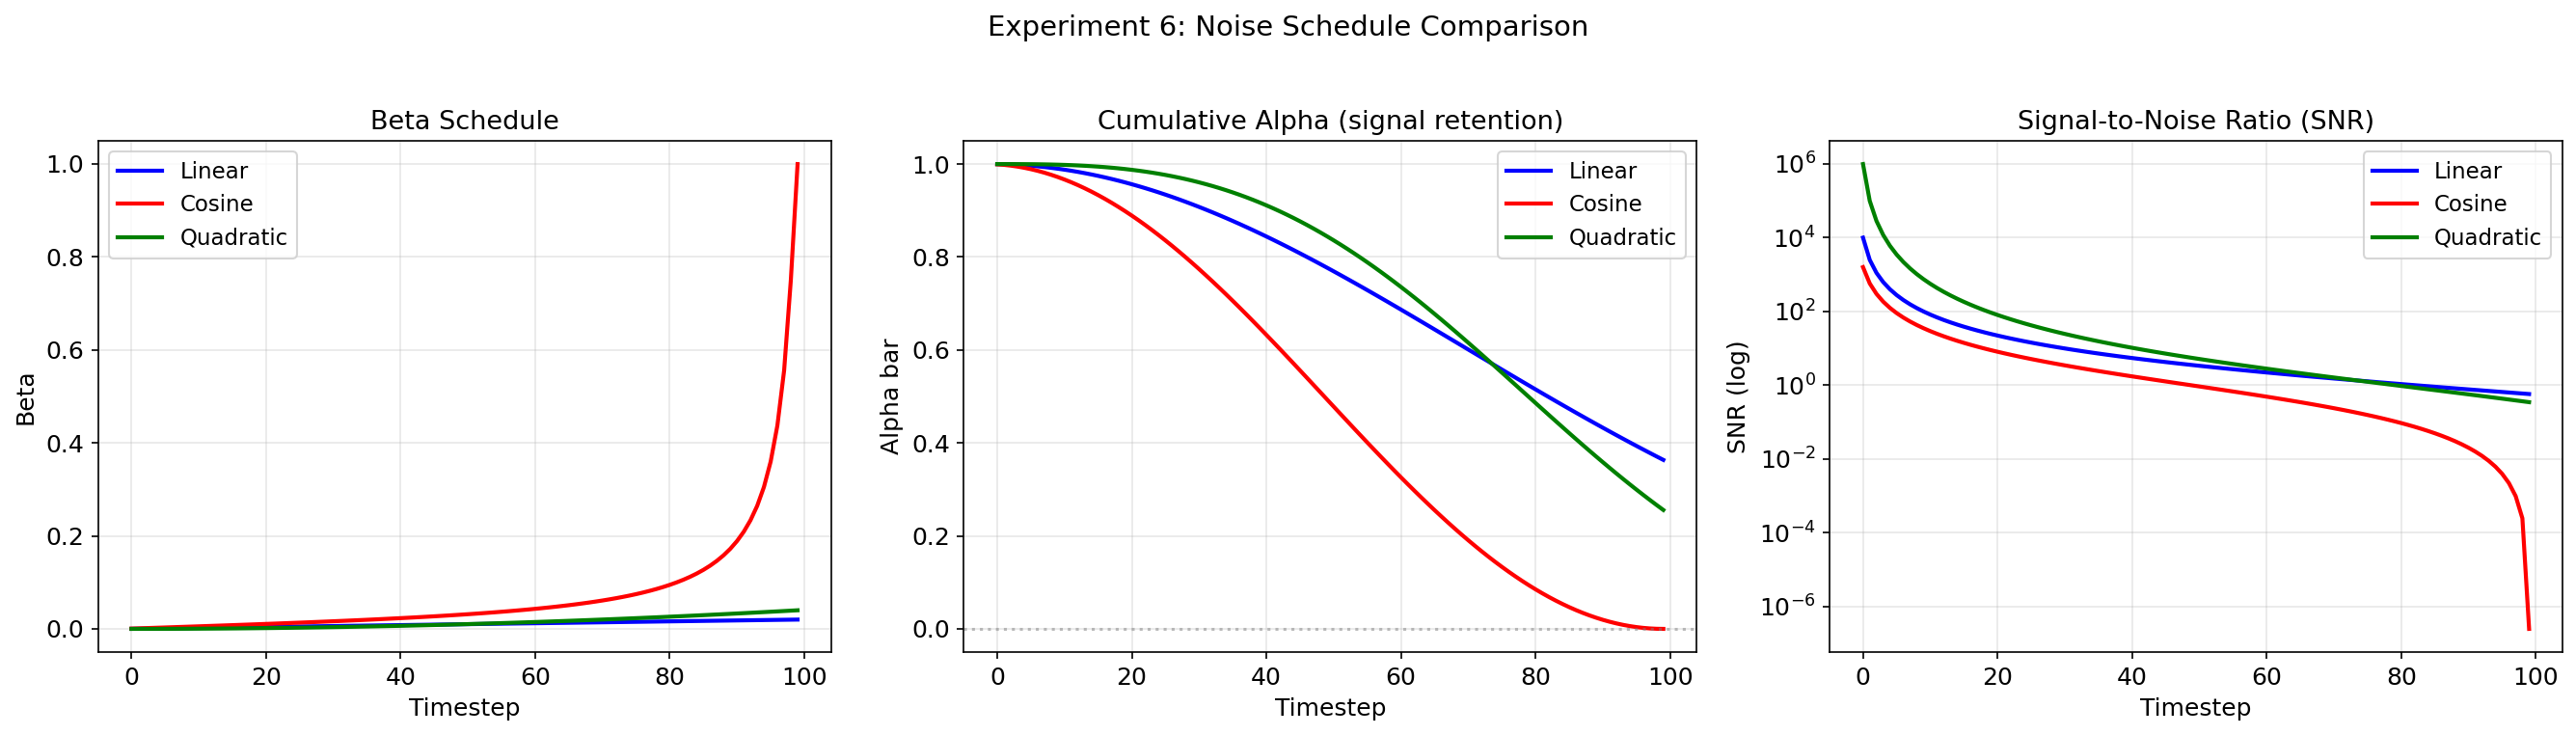

In [42]:
# Experiment 6: Noise schedule comparison
import numpy as np
import matplotlib.pyplot as plt

T = 100

# Linear schedule
beta_linear = np.linspace(1e-4, 0.02, T)

# Cosine schedule
steps = np.arange(T + 1) / T
s = 0.008
alphas_cos = np.cos((steps + s) / (1 + s) * np.pi * 0.5) ** 2
alphas_cos = alphas_cos / alphas_cos[0]
beta_cos = 1 - alphas_cos[1:] / alphas_cos[:-1]
beta_cos = np.clip(beta_cos, 1e-5, 0.999)

# Quadratic schedule
beta_quad = np.linspace(1e-4, 0.02, T) ** 2 * 100

# Compute alpha_bars
ab_linear = np.cumprod(1 - beta_linear)
ab_cos = np.cumprod(1 - beta_cos)
ab_quad = np.cumprod(1 - beta_quad)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Beta comparison
axes[0].plot(range(T), beta_linear, 'b-', linewidth=2, label='Linear')
axes[0].plot(range(T), beta_cos, 'r-', linewidth=2, label='Cosine')
axes[0].plot(range(T), beta_quad, 'g-', linewidth=2, label='Quadratic')
axes[0].set_title('Beta Schedule', fontsize=13)
axes[0].set_xlabel('Timestep', fontsize=12)
axes[0].set_ylabel('Beta', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Alpha_bar comparison
axes[1].plot(range(T), ab_linear, 'b-', linewidth=2, label='Linear')
axes[1].plot(range(T), ab_cos, 'r-', linewidth=2, label='Cosine')
axes[1].plot(range(T), ab_quad, 'g-', linewidth=2, label='Quadratic')
axes[1].set_title('Cumulative Alpha (signal retention)', fontsize=13)
axes[1].set_xlabel('Timestep', fontsize=12)
axes[1].set_ylabel('Alpha bar', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='gray', linestyle=':', alpha=0.5)

# SNR comparison
snr_linear = ab_linear / (1 - ab_linear + 1e-8)
snr_cos = ab_cos / (1 - ab_cos + 1e-8)
snr_quad = ab_quad / (1 - ab_quad + 1e-8)

axes[2].semilogy(range(T), snr_linear, 'b-', linewidth=2, label='Linear')
axes[2].semilogy(range(T), snr_cos, 'r-', linewidth=2, label='Cosine')
axes[2].semilogy(range(T), snr_quad, 'g-', linewidth=2, label='Quadratic')
axes[2].set_title('Signal-to-Noise Ratio (SNR)', fontsize=13)
axes[2].set_xlabel('Timestep', fontsize=12)
axes[2].set_ylabel('SNR (log)', fontsize=12)
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Experiment 6: Noise Schedule Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('nb10_exp_noise_schedule.png', dpi=150)
plt.show()
print("Figure saved: nb10_exp_noise_schedule.png")
print("\nCosine schedule: smoother signal decay, better quality")
print(f"  Linear: final alpha_bar = {ab_linear[-1]:.6f}")
print(f"  Cosine: final alpha_bar = {ab_cos[-1]:.6f}")
print(f"  Quadratic: final alpha_bar = {ab_quad[-1]:.6f}")


---
# 实验总结

### 关键发现

1. **三种范式的本质区别**
   - **GAN**: 对抗博弈, 无显式概率密度, 高质量但训练不稳定
   - **VAE**: 变分推断, 显式概率密度, 稳定但样本偏模糊
   - **Diffusion**: 逐步去噪, 高质量且稳定, 但采样速度慢

2. **训练稳定性排序**
   - Diffusion ≈ VAE >> GAN
   - GAN的对抗训练本质上不稳定 (minimax博弈)
   - VAE和Diffusion有明确的优化目标

3. **生成质量排序**
   - Diffusion > GAN > VAE
   - Diffusion通过多步去噪达到最高质量
   - VAE的模糊源于重建损失和KL正则的权衡

4. **采样速度排序**
   - GAN ≈ VAE >> Diffusion
   - GAN和VAE: 单次前向传播
   - Diffusion: 需要T步迭代 (T通常100-1000)

### 设计原则

| 模型 | 适用场景 | 关键超参数 |
|------|---------|-----------|
| GAN | 需要高质量, 可接受不稳定 | lr平衡, 架构设计 |
| VAE | 需要稳定训练, 显式表示 | KL权重(beta), 潜在维度 |
| Diffusion | 需要最高质量, 可接受慢 | 噪声调度, T步数 |


---
# 作业

## 作业1: 实现DCGAN的关键组件

**任务**: 实现DCGAN (Deep Convolutional GAN) 的核心组件。

**要求**:
1. 实现转置卷积 (用于Generator上采样)
2. 实现步长卷积 (用于Discriminator下采样)
3. 实现BatchNorm层 (复用lecture-6的实现)
4. 实现LeakyReLU激活 (slope=0.2)
5. 组装完整的DCGAN Generator和Discriminator
6. 在2D合成数据上测试 (使用1D "图像")

**提示**:
- Generator: z -> reshape -> ConvT -> BN -> LeakyReLU -> ConvT -> tanh
- Discriminator: x -> Conv -> LeakyReLU -> Conv -> sigmoid

---

## 作业2: 分析VAE的beta参数

**任务**: 分析beta-VAE中beta参数对生成质量的影响。

**要求**:
1. 实现beta-VAE: $L = \text{recon} + \beta \cdot KL$
2. 测试beta值: [0.01, 0.1, 1.0, 5.0, 10.0]
3. 对每个beta训练100个epoch
4. 记录: 重建损失, KL损失, 生成样本统计量
5. 可视化: 不同beta下的潜在空间分布
6. 分析: beta如何控制重建-正则化权衡?

**预期**:
- beta=0: 无正则, 潜在空间不连续 (退化为AE)
- beta=1: 标准VAE, 平衡
- beta=10: 过度正则, 生成质量下降 (模糊)

---

## 作业3: 实现DDIM快速采样

**任务**: 实现DDIM (Denoising Diffusion Implicit Models) 加速采样。

**要求**:
1. 理解DDIM的核心: 非马尔可夫采样, 可以跳步
2. 实现DDIM采样公式:
   $$x_{t-1} = \sqrt{\alpha_{t-1}} \hat{x}_0 + \sqrt{1-\alpha_{t-1}} \epsilon_\theta$$
   其中 $\hat{x}_0 = (x_t - \sqrt{1-\alpha_t} \epsilon) / \sqrt{\alpha_t}$
3. 用50步DDIM vs 1000步DDPM对比
4. 测量采样时间和生成质量
5. 可视化不同步数的生成结果

**预期**:
- DDIM 50步 ≈ DDPM 1000步的质量
- DDIM采样速度提升约20倍

**提交**: 代码 + 对比图表 + 分析报告


---
# 参考文献

1. **GAN**: Goodfellow, I., et al. (2014). *Generative Adversarial Nets*. NeurIPS.
   - 开创性工作, 提出对抗训练框架

2. **DCGAN**: Radford, A., Metz, L., & Chintala, S. (2015). *Unsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks*. ICLR 2016.
   - 将CNN引入GAN, 训练更稳定

3. **VAE**: Kingma, D. P., & Welling, M. (2013). *Auto-Encoding Variational Bayes*. ICLR 2014.
   - 提出变分自编码器, 重参数化技巧

4. **beta-VAE**: Higgins, I., et al. (2017). *beta-VAE: Learning Basic Visual Concepts with a Constrained Variational Bias*. ICLR 2017.
   - 通过beta参数控制KL正则化强度

5. **DDPM**: Ho, J., Jain, A., & Abbeel, P. (2020). *Denoising Diffusion Probabilistic Models*. NeurIPS.
   - 现代扩散模型的奠基工作

6. **Improved DDPM**: Nichol, A., & Dhariwal, P. (2021). *Improved Denoising Diffusion Probabilistic Models*. ICML.
   - 改进噪声调度 (余弦调度), 学习方差

7. **DDIM**: Song, J., Meng, C., & Ermon, S. (2020). *Denoising Diffusion Implicit Models*. ICLR 2021.
   - 非马尔可夫采样, 加速20-50倍

8. **Stable Diffusion**: Rombach, R., et al. (2022). *High-Resolution Image Synthesis with Latent Diffusion Models*. CVPR.
   - 潜在空间扩散, 文本到图像生成

9. **CS231n Course**: Johnson, J. & Fei-Fei, L. *CS231n: Convolutional Neural Networks for Visual Recognition*. Stanford University.

---

*本notebook由CS231n课程材料启发, 所有代码实现仅使用NumPy和Matplotlib, 可独立运行。*


---

## 参考代码实现

以下 GitHub 仓库提供了本节内容的完整代码实现，建议结合学习：

- **[labmlai/annotated_deep_learning_paper_implementations](https://github.com/labmlai/annotated_deep_learning_paper_implementations)** (67433 stars): GAN、CycleGAN、StyleGAN2 带注释实现
  - 仓库地址: https://github.com/labmlai/annotated_deep_learning_paper_implementations

- **[MorvanZhou/PyTorch-Tutorial](https://github.com/MorvanZhou/PyTorch-Tutorial)** (8466 stars): GAN 与 AutoEncoder 中文教程
  - 仓库地址: https://github.com/MorvanZhou/PyTorch-Tutorial

- **[Mikoto10032/DeepLearning](https://github.com/Mikoto10032/DeepLearning)** (17759 stars): 深度学习入门（含 GAN/RNN/CNN 教程）
  - 仓库地址: https://github.com/Mikoto10032/DeepLearning


> 标注说明: 以上仓库按热度排序，优先推荐 stars 最多的实现。

